In [1]:
import pandas as pd

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')
plt.rcParams.update({'font.size': 10})

In [2]:
hydro_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_hydrologic_attributes.csv'
hydro = pd.read_csv(hydro_path)
hydro = hydro.set_index('gauge_id')

meta_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_meta_attributes.csv'
meta = pd.read_csv(meta_path)
meta = meta.set_index('gauge_id')

human_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_humaninfluence_attributes.csv'
human = pd.read_csv(human_path)
human = human.set_index('gauge_id')

clim_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_climatic_attributes.csv'
clim = pd.read_csv(clim_path)
clim = clim.set_index('gauge_id')

land_path = '/media/iielse/T9/CAMELS-FI/data/CAMELS_FI_landcover_attributes.csv'
land = pd.read_csv(land_path)
land = land.set_index('gauge_id')

In [3]:
df = hydro.join(meta[['water_region_code', 'water_region_name']])
df = df.join(human[['regulation_level']])
df = df.join(clim)
df = df.join(land)
# Indices are plotted only for nonregulated catchments
df = df[df['regulation_level']==1]

In [4]:
def preprocess_box(df, column_name):
    """ Preprocesses the given column to the right format for boxplot
    """
    coast = df[df['water_region_code'] == 1]
    lakes = df[df['water_region_code'] == 2]
    lapland = df[df['water_region_code'] == 3]
    plot_data = [coast[column_name].values, lakes[column_name].values, lapland[column_name].values]
    return plot_data

# Regional plot collection
## climate

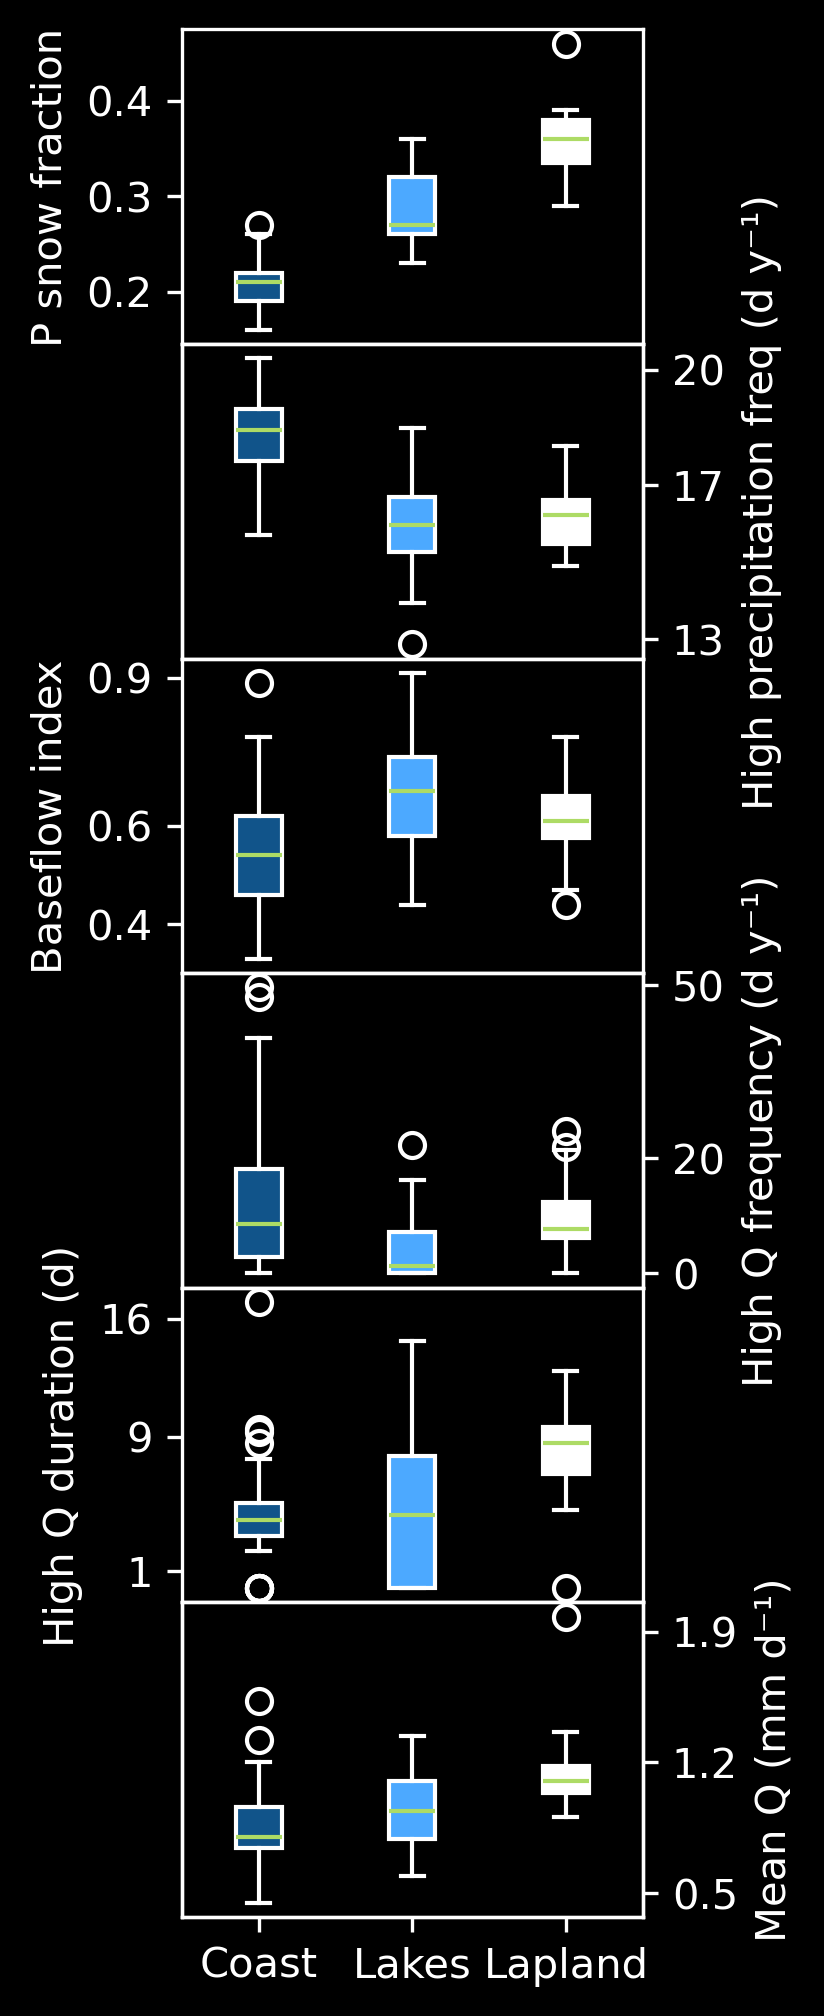

In [5]:
# Matplotlib uses inches, I don't
cm_conversion = 1 / 2.54

width = 6.5
heigth = 17

columns = ['frac_snow', 'high_prec_freq','baseflow_index_ladson', 'high_q_freq', 'high_q_dur', 'q_mean']
ylabels = ['P snow fraction', 'High precipitation freq (d y⁻¹)','Baseflow index','High Q frequency (d y⁻¹)', 'High Q duration (d)', 'Mean Q (mm d⁻¹)']
precision = [1, 0, 1,-1, 0, 1]

fig, axs = plt.subplots(nrows=len(columns), figsize=(width*cm_conversion, heigth*cm_conversion))

for i, info in enumerate(zip(axs, columns)):
    ax, column = info
    
    # for odd values of i, the labels are set to the right
    if i % 2 == 1:
        orig_ax = ax
        ax = ax.twinx()
        orig_ax.yaxis.set_visible(False)
        
    plot_data = preprocess_box(df, column)

    colors = ['#11548a', '#4ca9ff', '#ffffff'] 
    
    
    labels = ['Coast', 'Lakes', 'Lapland']
    
    # only the last row needs x labels
    if i == len(columns)-1:
        bplot = ax.boxplot(
            plot_data, patch_artist=True, tick_labels=labels,
            medianprops=dict(color='#addb65'))
    else:
        bplot = ax.boxplot(
            plot_data, patch_artist=True,
            medianprops=dict(color='#addb65'))
        ax.set_xticklabels([])

    # Add a letter corresponding to plot to the upper left corner
    """
    letter = chr(ord('a') + i)
    ax.text(0.015, 0.95, f'{letter})', transform=ax.transAxes,
        fontsize=12, verticalalignment='top')
    """
    # fill with colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
    
    # three values are sufficient for a scale
    ylim = ax.get_ylim()
    ymin = ylim[0]
    ymax = ylim[1]
    yrange = ymax-ymin
    tick_pos = 0.1 # set the label proportionally this much higher (or lower) than min (max)
    ax.set_yticks([round(ymin + yrange*tick_pos, precision[i]), round(ymin + yrange*0.5, precision[i]),  round(ymax - yrange*tick_pos, precision[i])])
    """
    yticks = ax.get_yticks()
    min_tick = yticks[1]
    max_tick = yticks[-2]
    ax.set_yticks([min_tick, max_tick])
    """
    ax.set_ylabel(ylabels[i])

    
plt.subplots_adjust(
    hspace=0.0, left=0.2, right=0.8,
    top=0.99, bottom=0.05)

plt.savefig('CAMELS-FI/figures/hydrocli_boxplot.png', transparent=True)


# regional plot
## land use

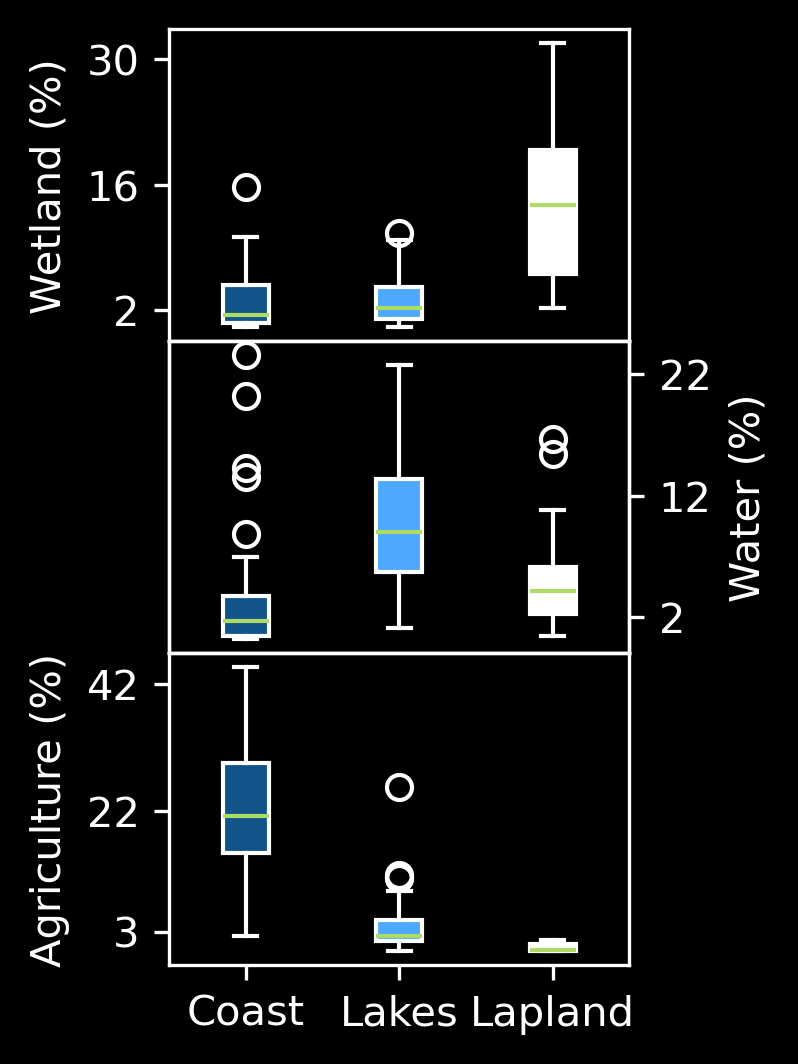

In [21]:
# Matplotlib uses inches, I don't
cm_conversion = 1 / 2.54

width = 6.5
heigth = 8.9

columns = ['wetland', 'inwater', 'crop']
columns = [f"{column}_perc_2018" for column in columns]
ylabels = ['Wetland (%)', 'Water (%)', 'Agriculture (%)']
precision = [0, 0, 0]

fig, axs = plt.subplots(nrows=len(columns), figsize=(width*cm_conversion, heigth*cm_conversion))

for i, info in enumerate(zip(axs, columns)):
    ax, column = info
    
    # for odd values of i, the labels are set to the right
    if i % 2 == 1:
        orig_ax = ax
        ax = ax.twinx()
        orig_ax.yaxis.set_visible(False)
        
    plot_data = preprocess_box(df, column)

    colors = ['#11548a', '#4ca9ff', '#ffffff'] 
    
    
    labels = ['Coast', 'Lakes', 'Lapland']
    
    # only the last row needs x labels
    if i == len(columns)-1:
        bplot = ax.boxplot(
            plot_data, patch_artist=True, tick_labels=labels,
            medianprops=dict(color='#addb65'))
    else:
        bplot = ax.boxplot(
            plot_data, patch_artist=True,
            medianprops=dict(color='#addb65'))
        ax.set_xticklabels([])

    # Add a letter corresponding to plot to the upper left corner
    """
    letter = chr(ord('a') + i)
    ax.text(0.015, 0.95, f'{letter})', transform=ax.transAxes,
        fontsize=12, verticalalignment='top')
    """
    # fill with colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)
    
    # three values are sufficient for a scale
    ylim = ax.get_ylim()
    ymin = ylim[0]
    ymax = ylim[1]
    yrange = ymax-ymin
    tick_pos = 0.1 # set the label proportionally this much higher (or lower) than min (max)
    ax.set_yticks([round(ymin + yrange*tick_pos, precision[i]), round(ymin + yrange*0.5, precision[i]),  round(ymax - yrange*tick_pos, precision[i])])
    """
    yticks = ax.get_yticks()
    min_tick = yticks[1]
    max_tick = yticks[-2]
    ax.set_yticks([min_tick, max_tick])
    """
    ax.set_ylabel(ylabels[i])

    
plt.subplots_adjust(
    hspace=0.0, left=0.2, right=0.8,
    top=0.99, bottom=0.1)
#plt.tight_layout()
plt.savefig('CAMELS-FI/figures/lc_boxplot.png', transparent=True)


# Hydrology plots

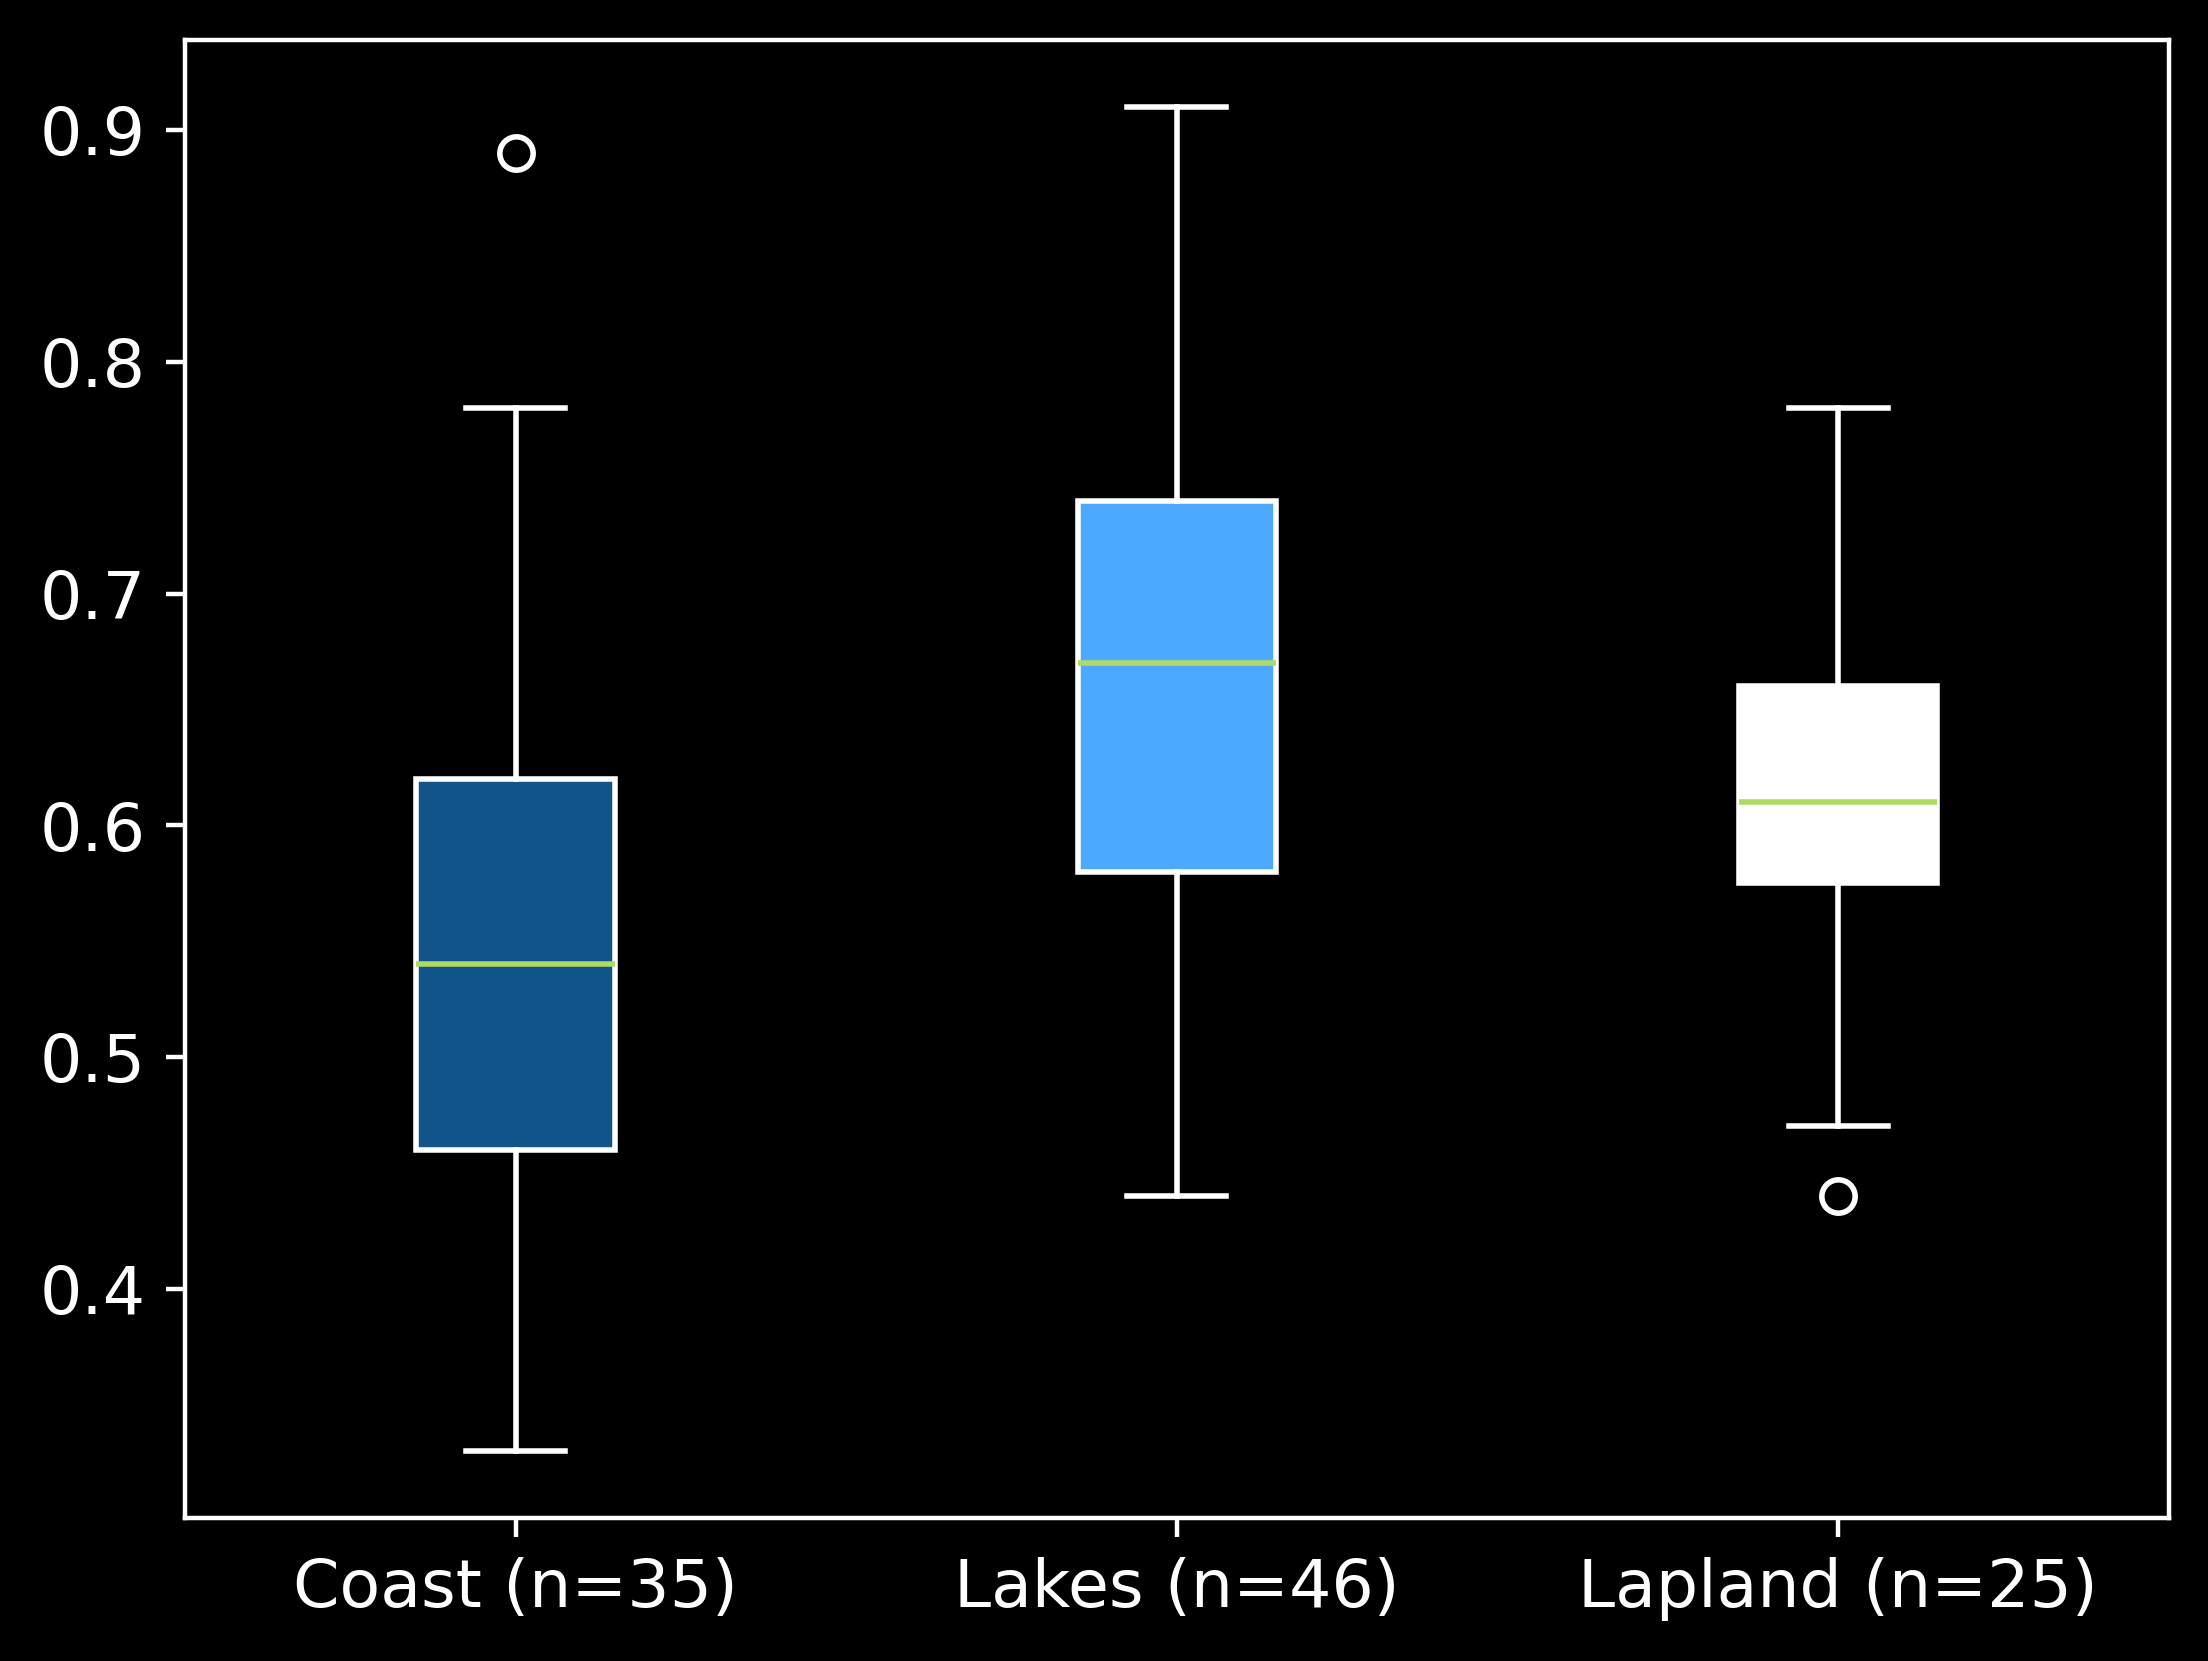

In [23]:

plot_data = preprocess(df, 'baseflow_index_ladson')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


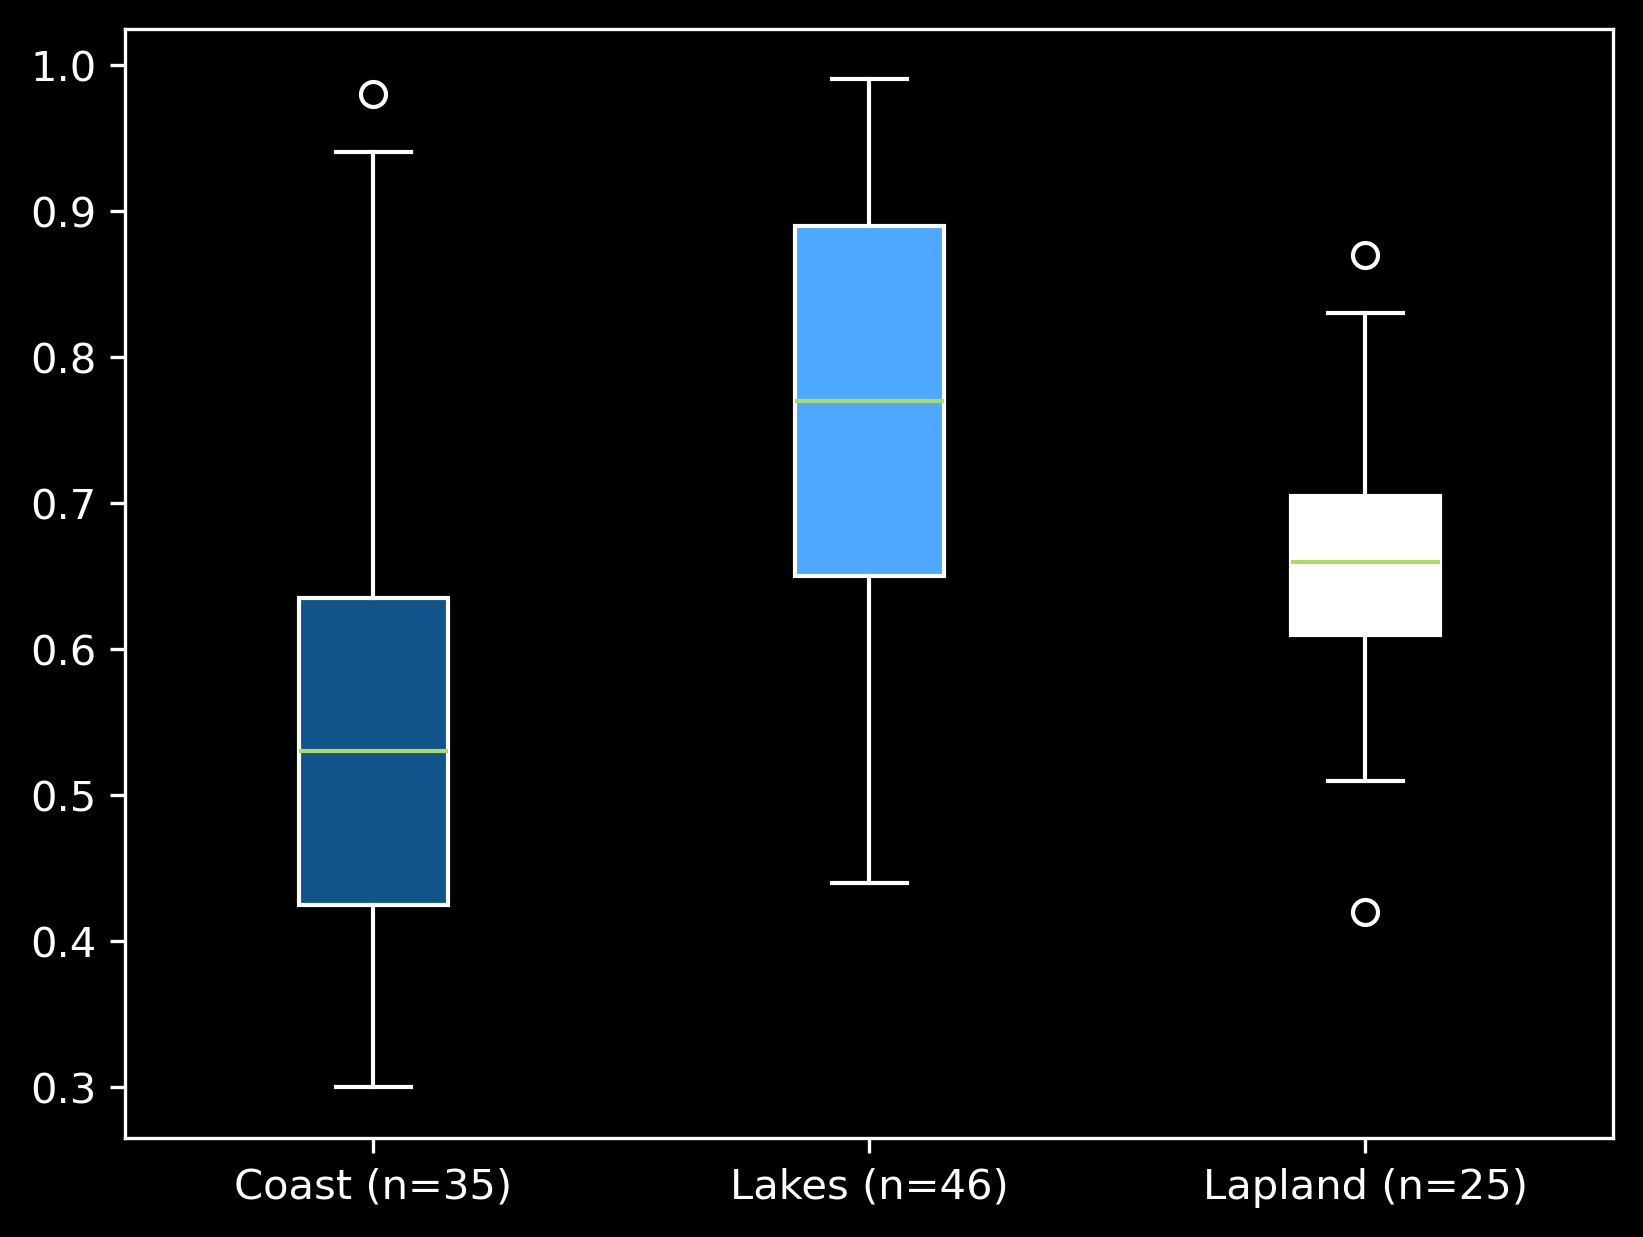

In [115]:

plot_data = preprocess(df, 'baseflow_index_lfstat')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


# Stream elasticity

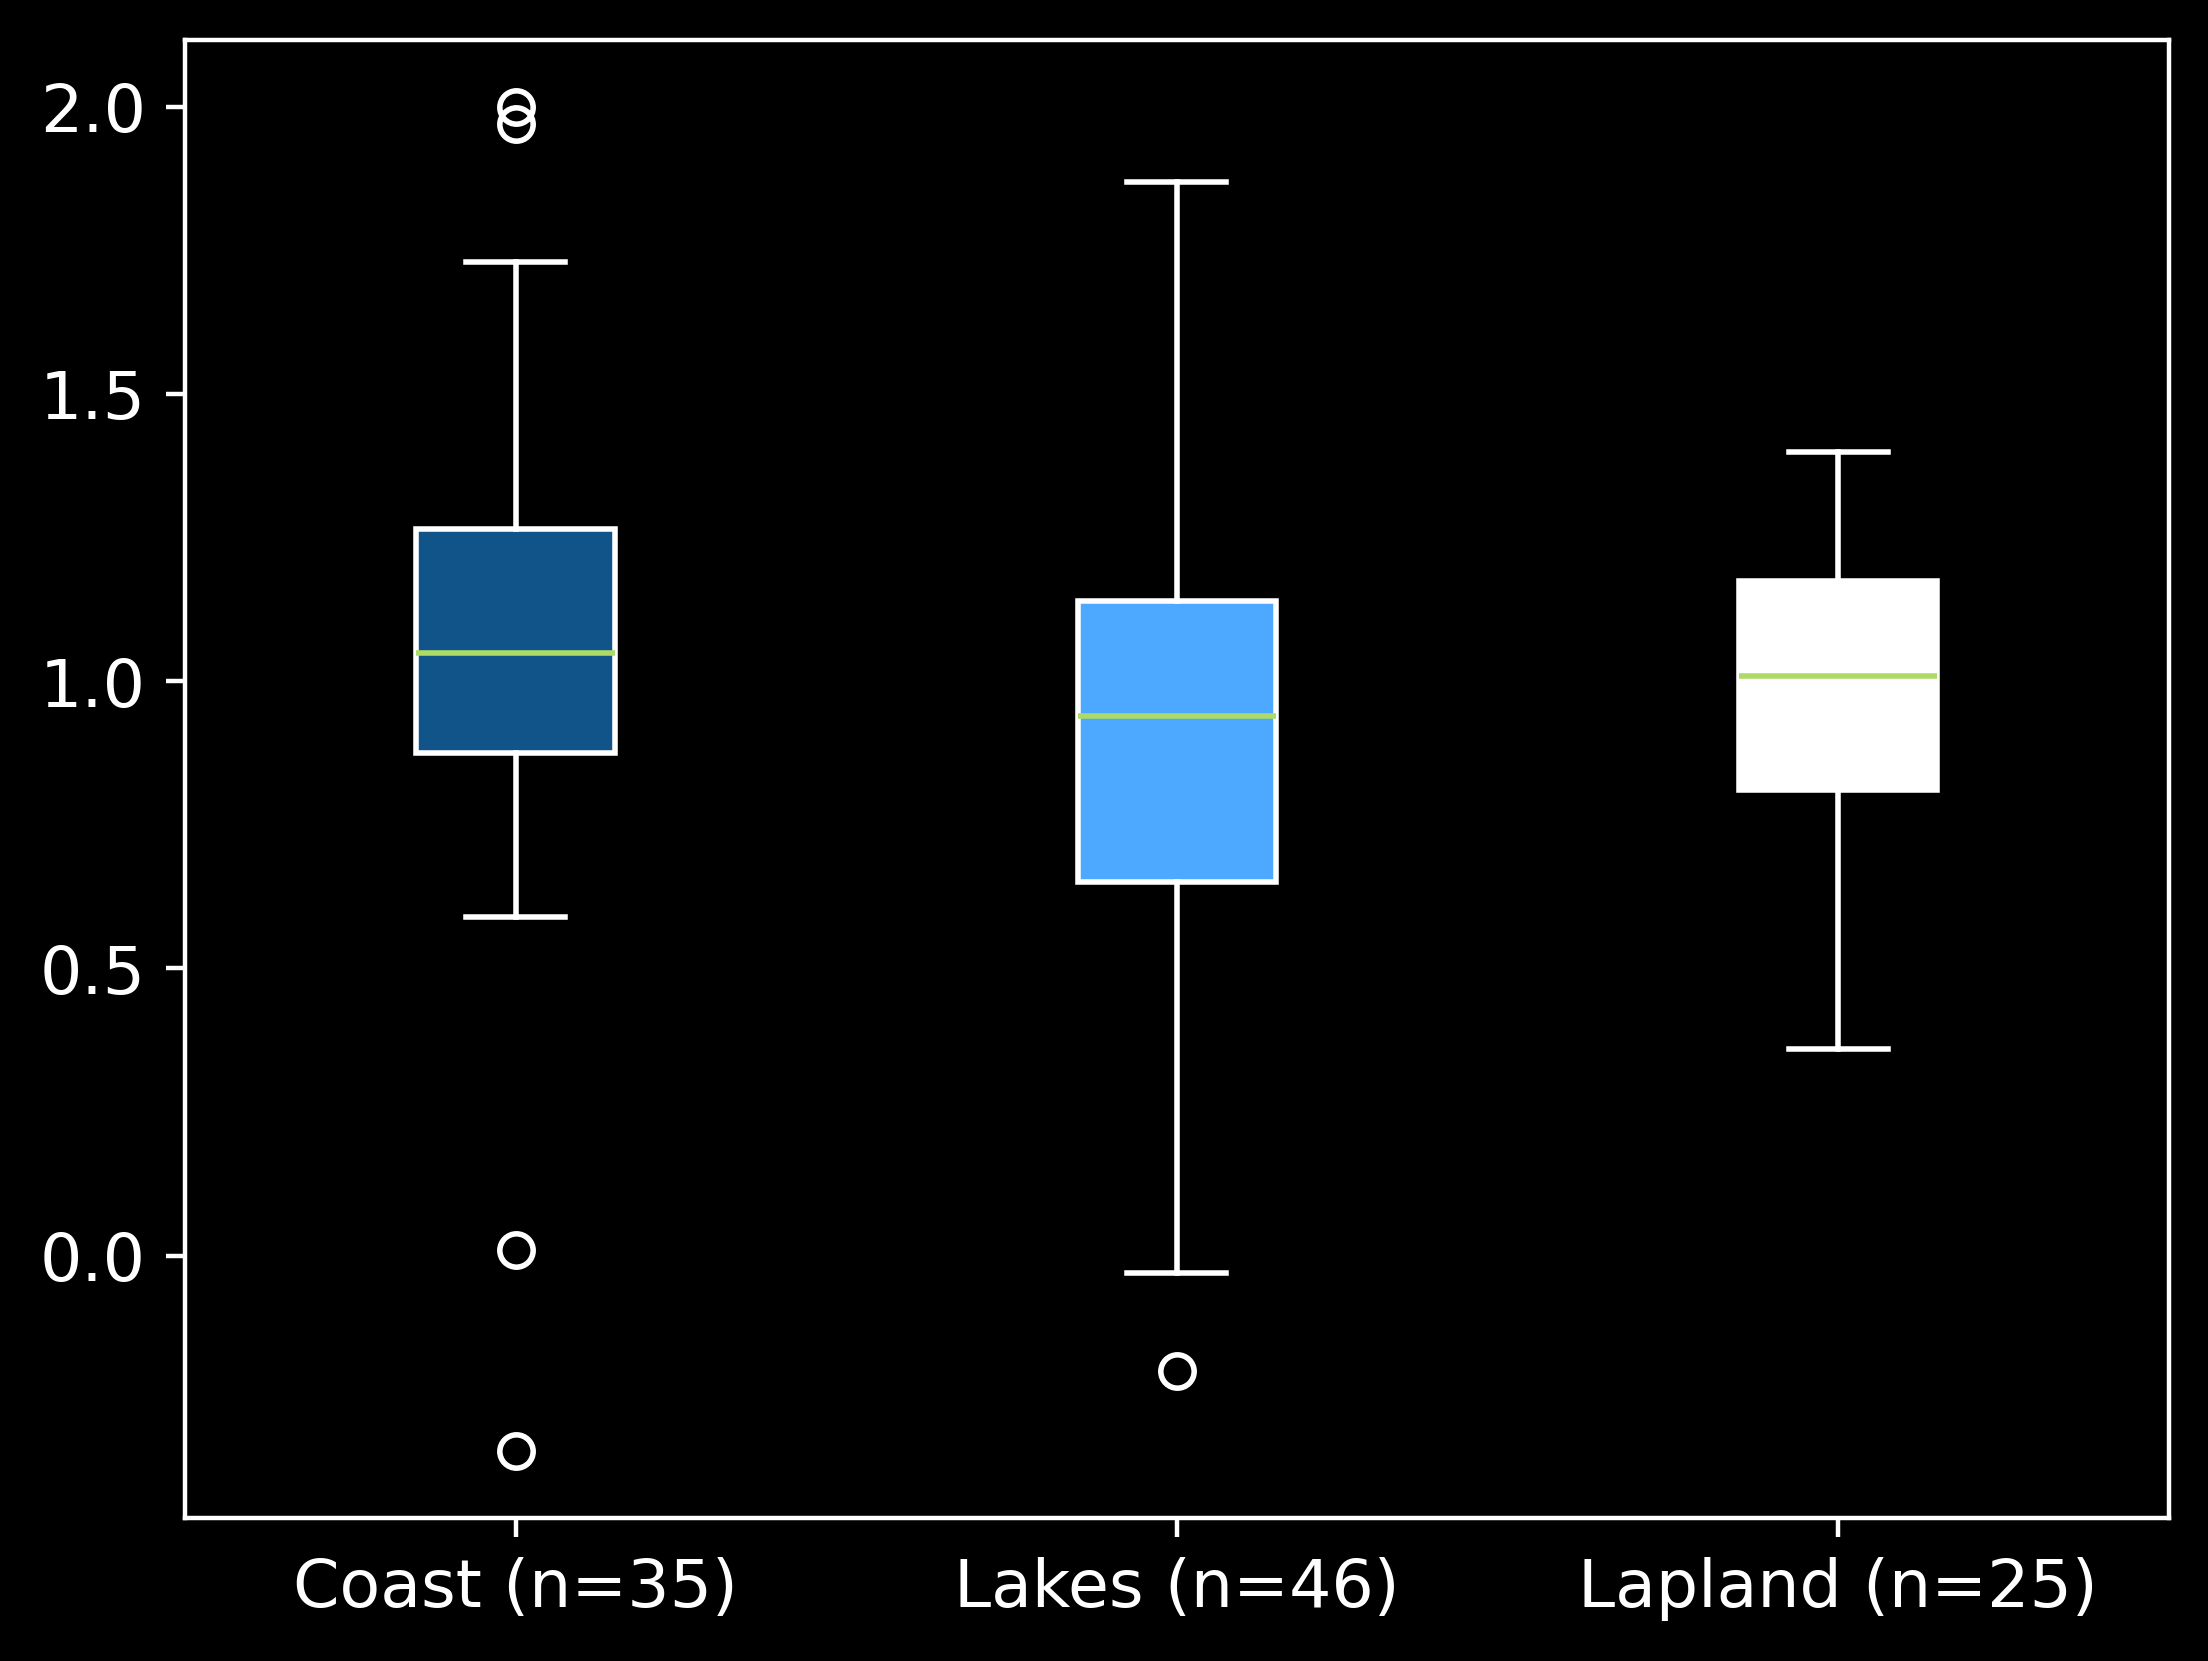

In [57]:

plot_data = preprocess(df, 'stream_elas')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


# HFD mean

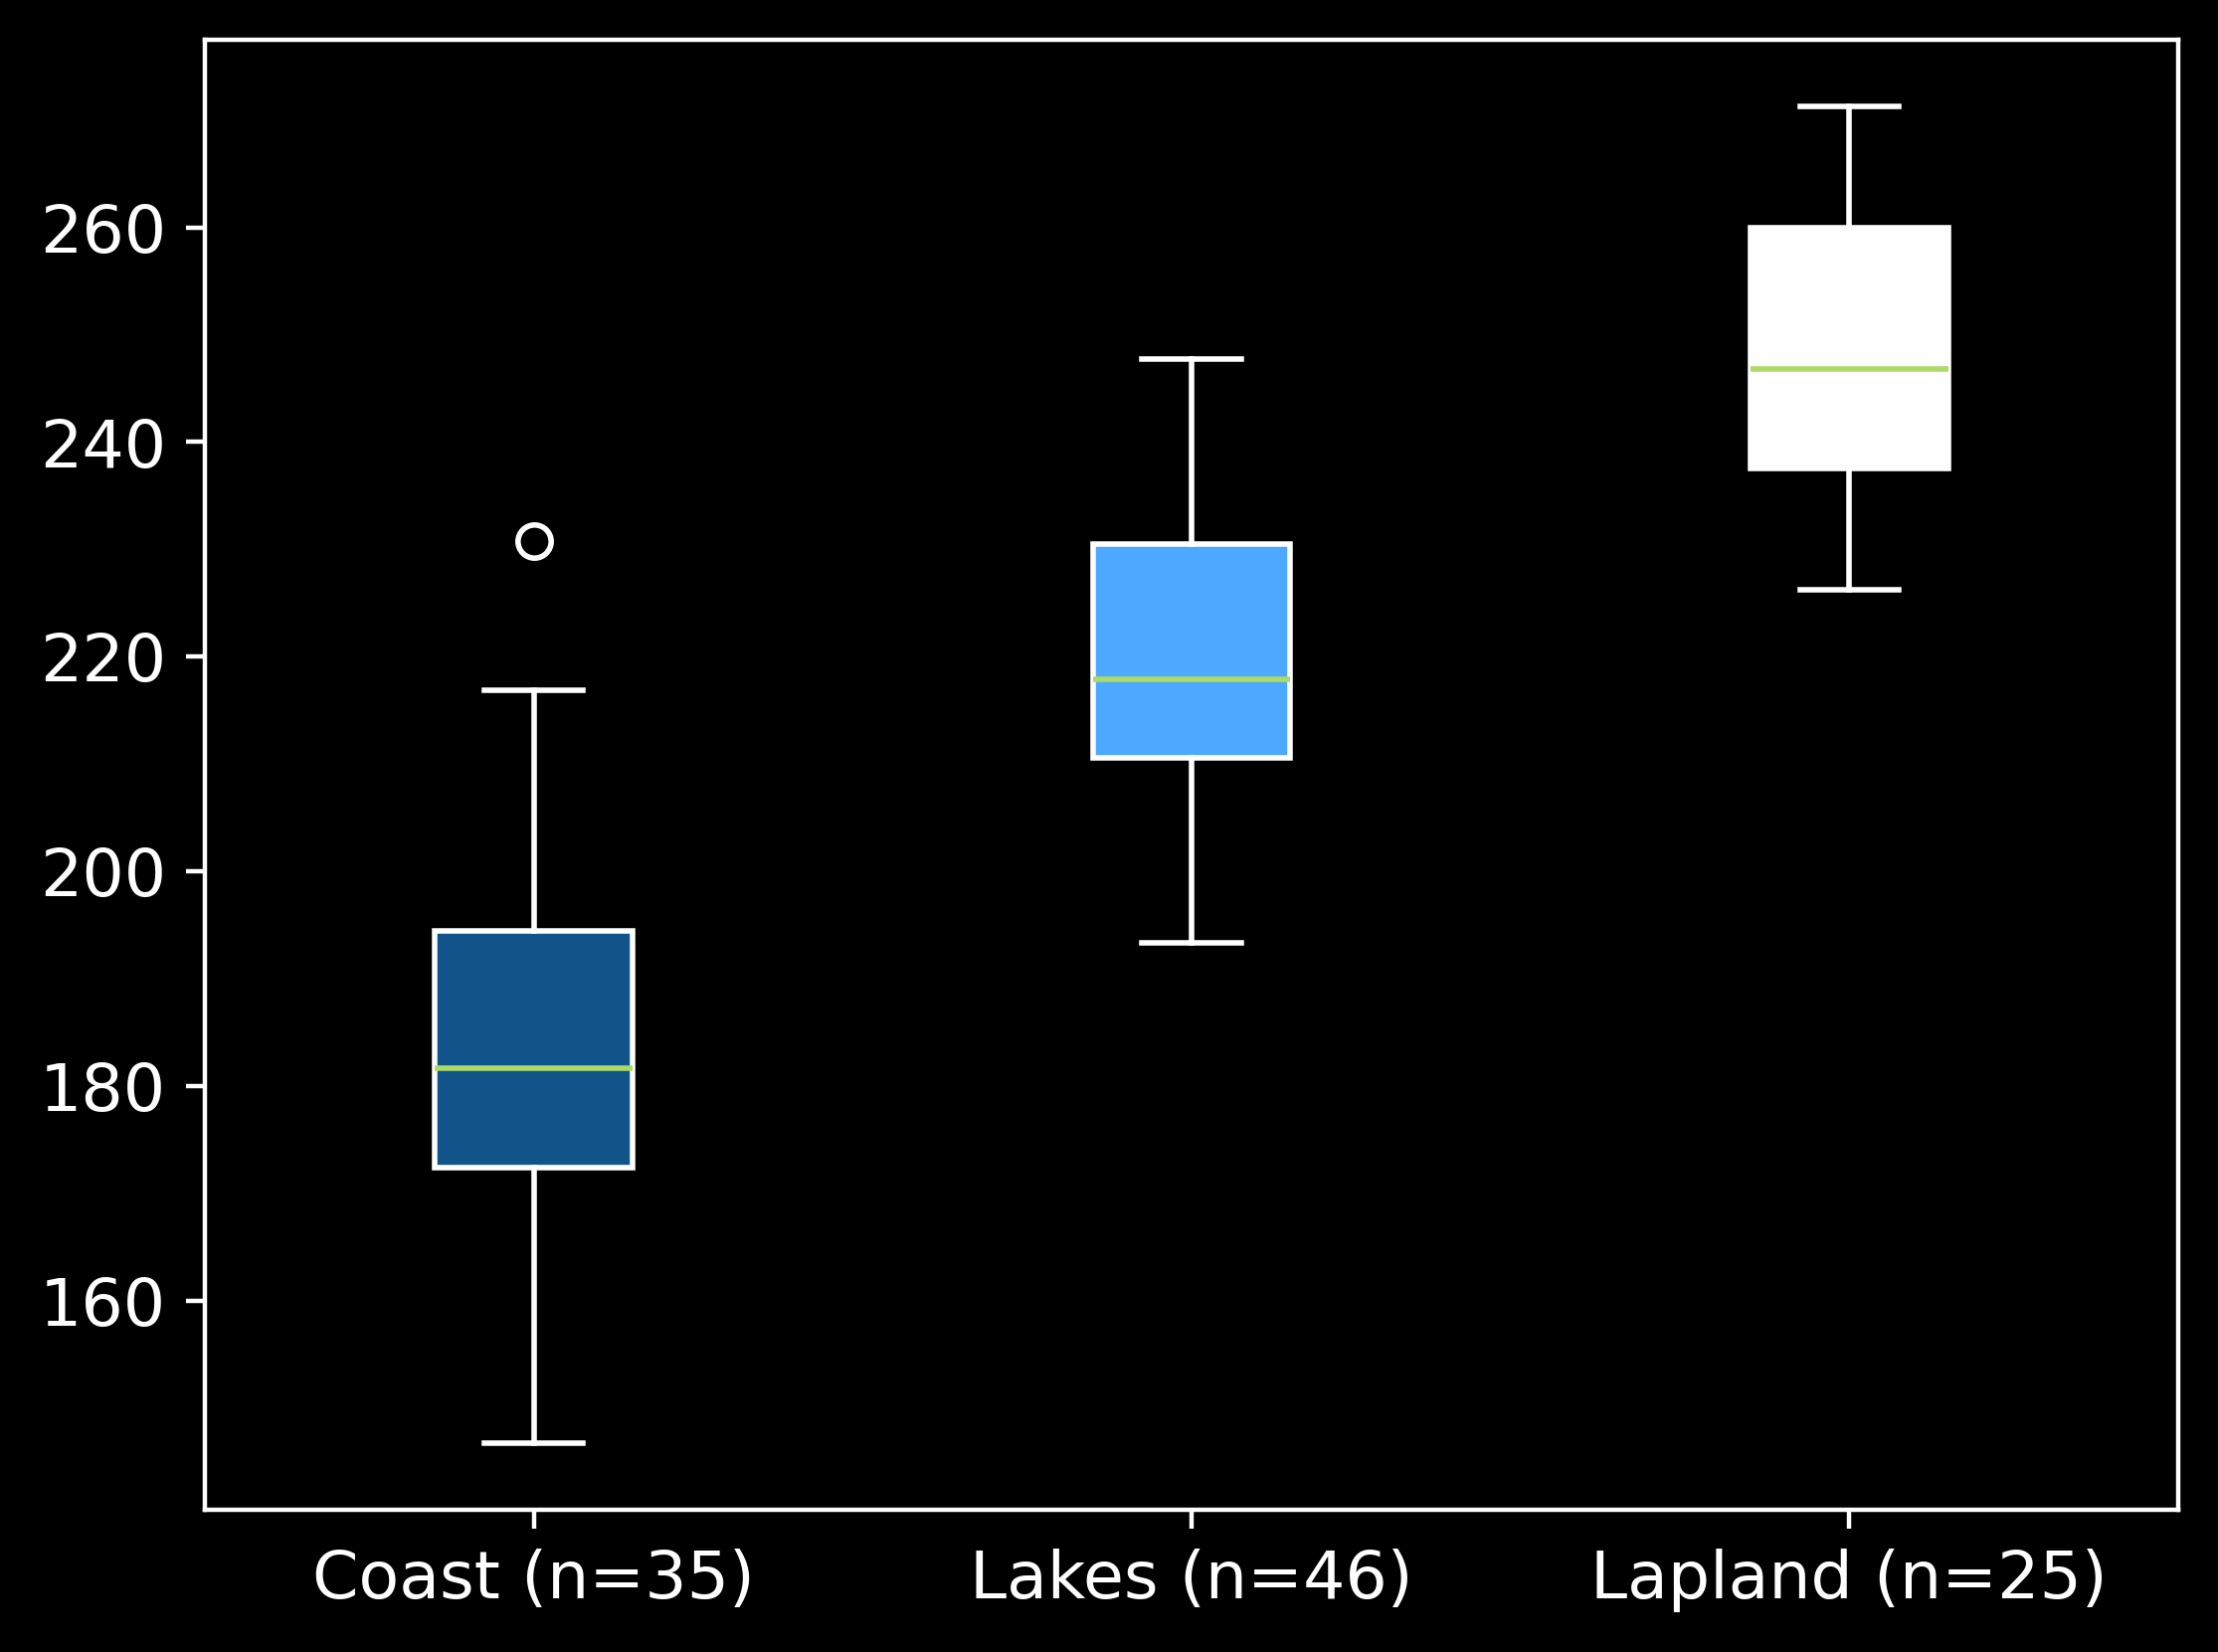

In [58]:

plot_data = preprocess(df, 'hfd_mean')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


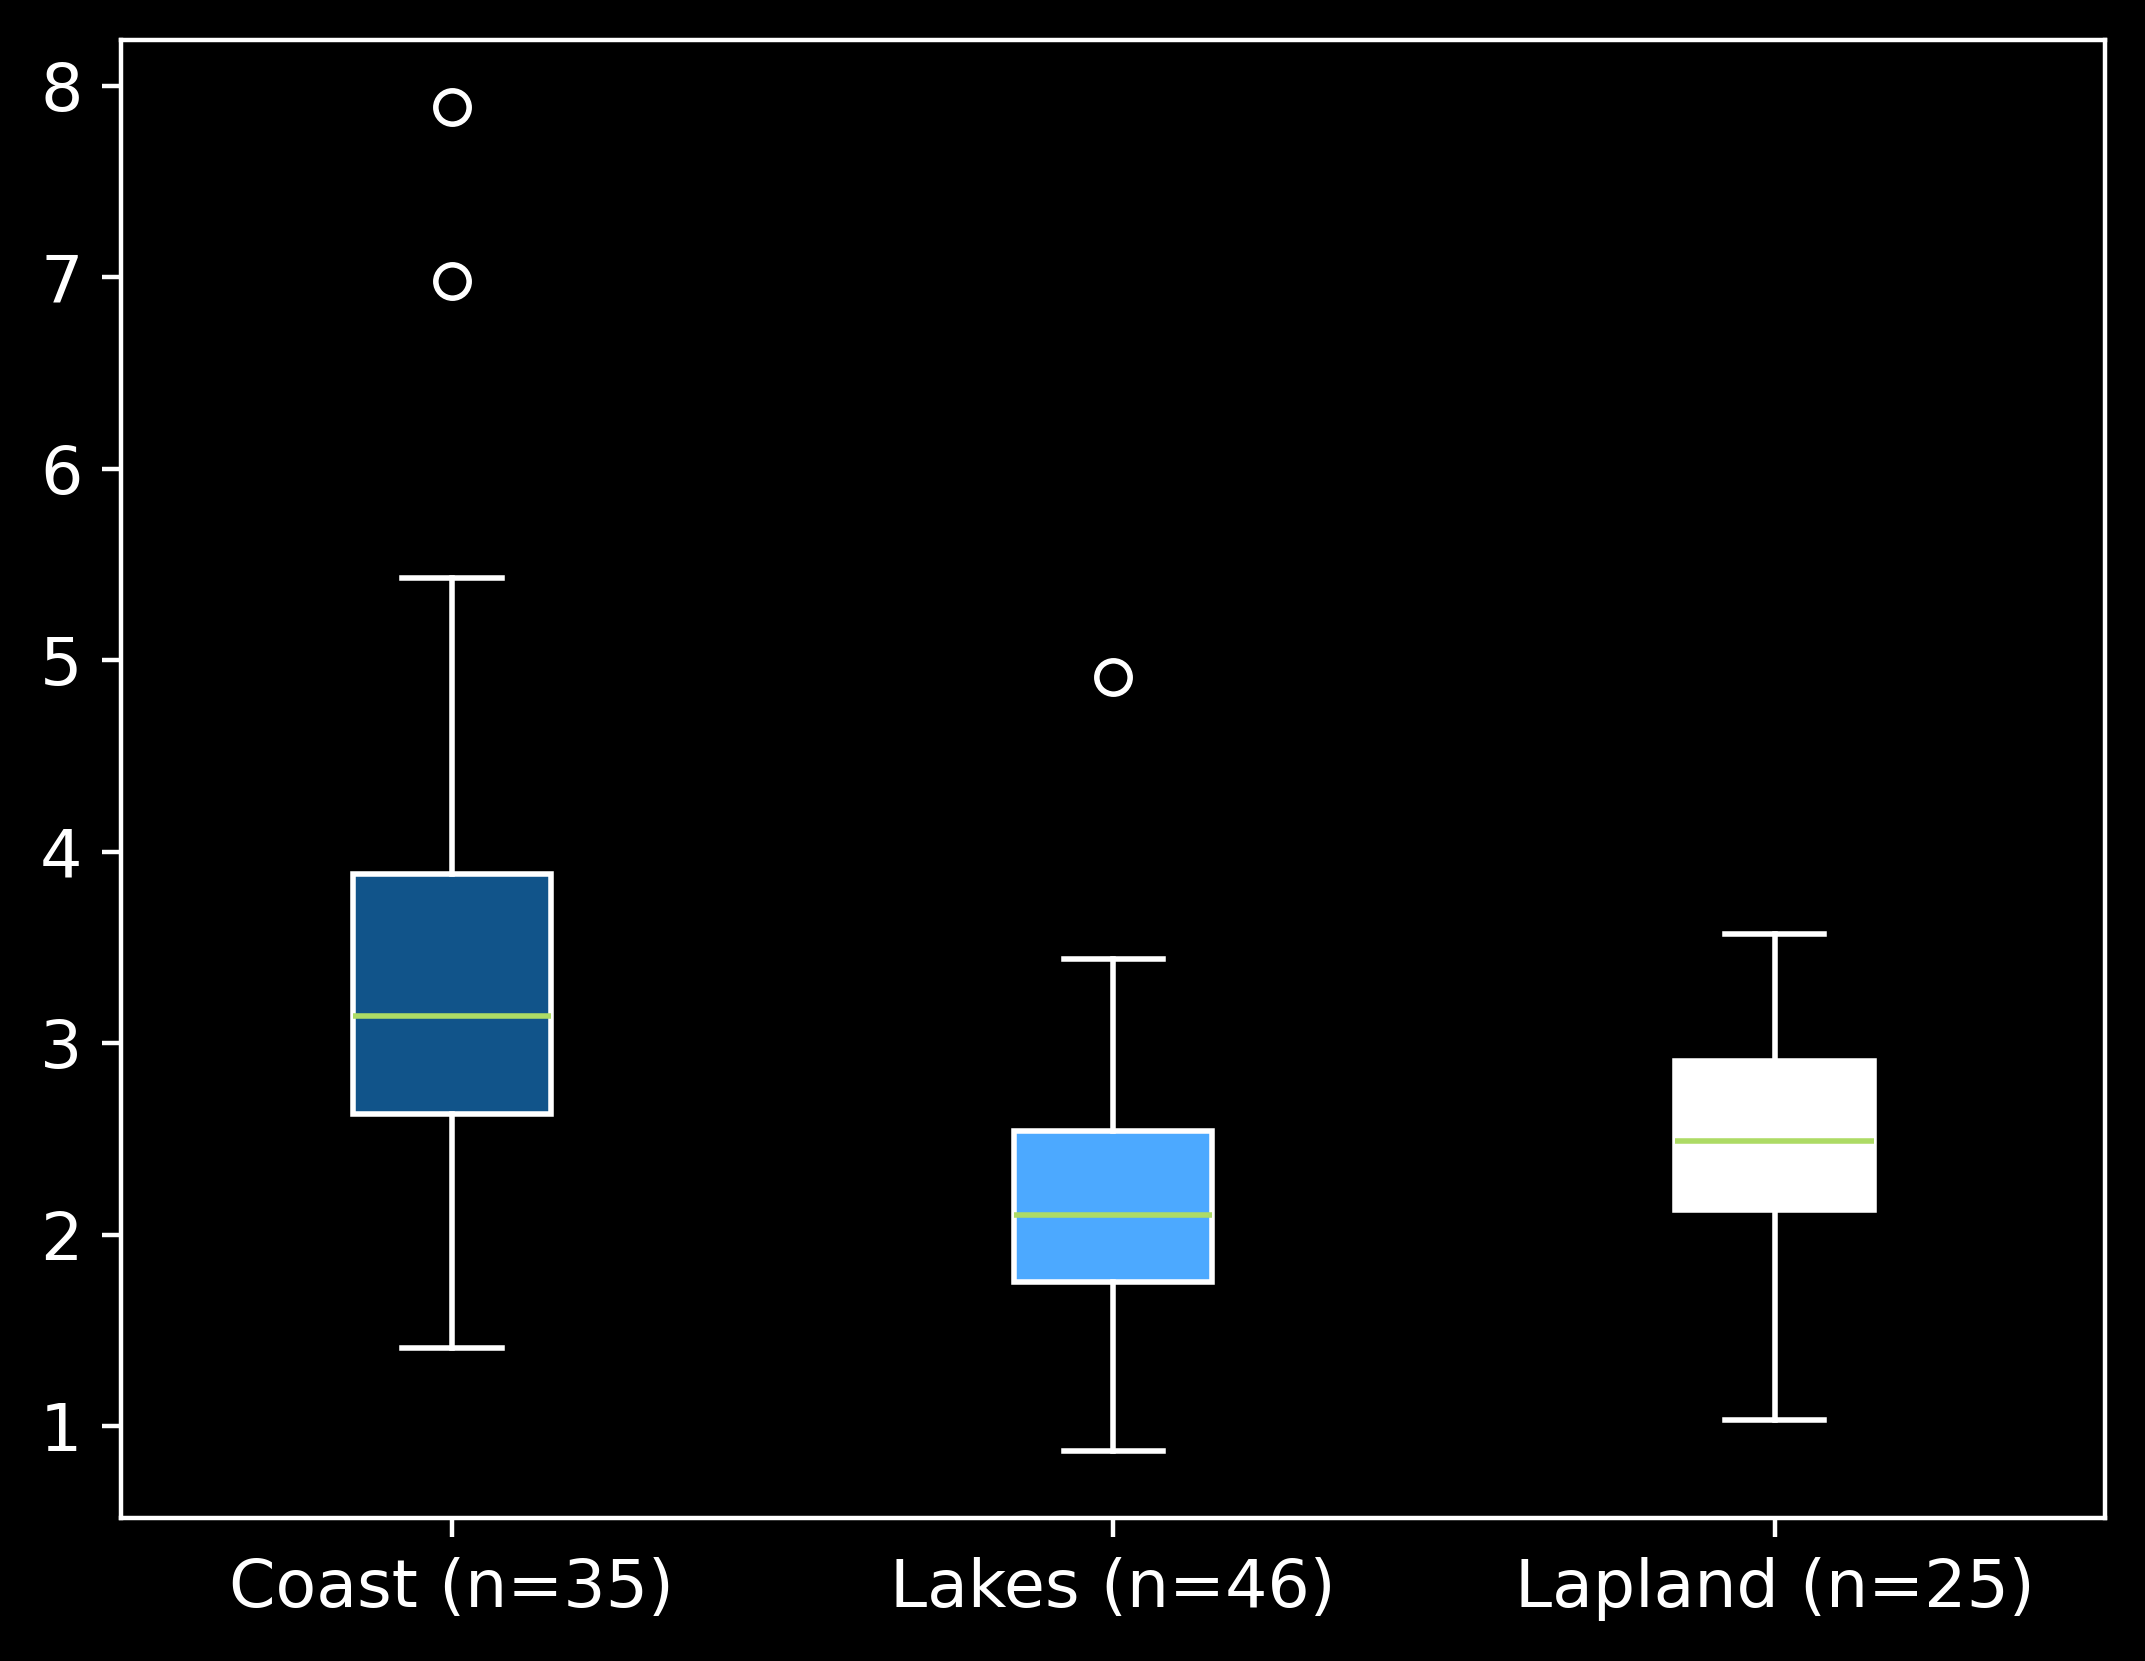

In [62]:

plot_data = preprocess(df, 'slope_fdc')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


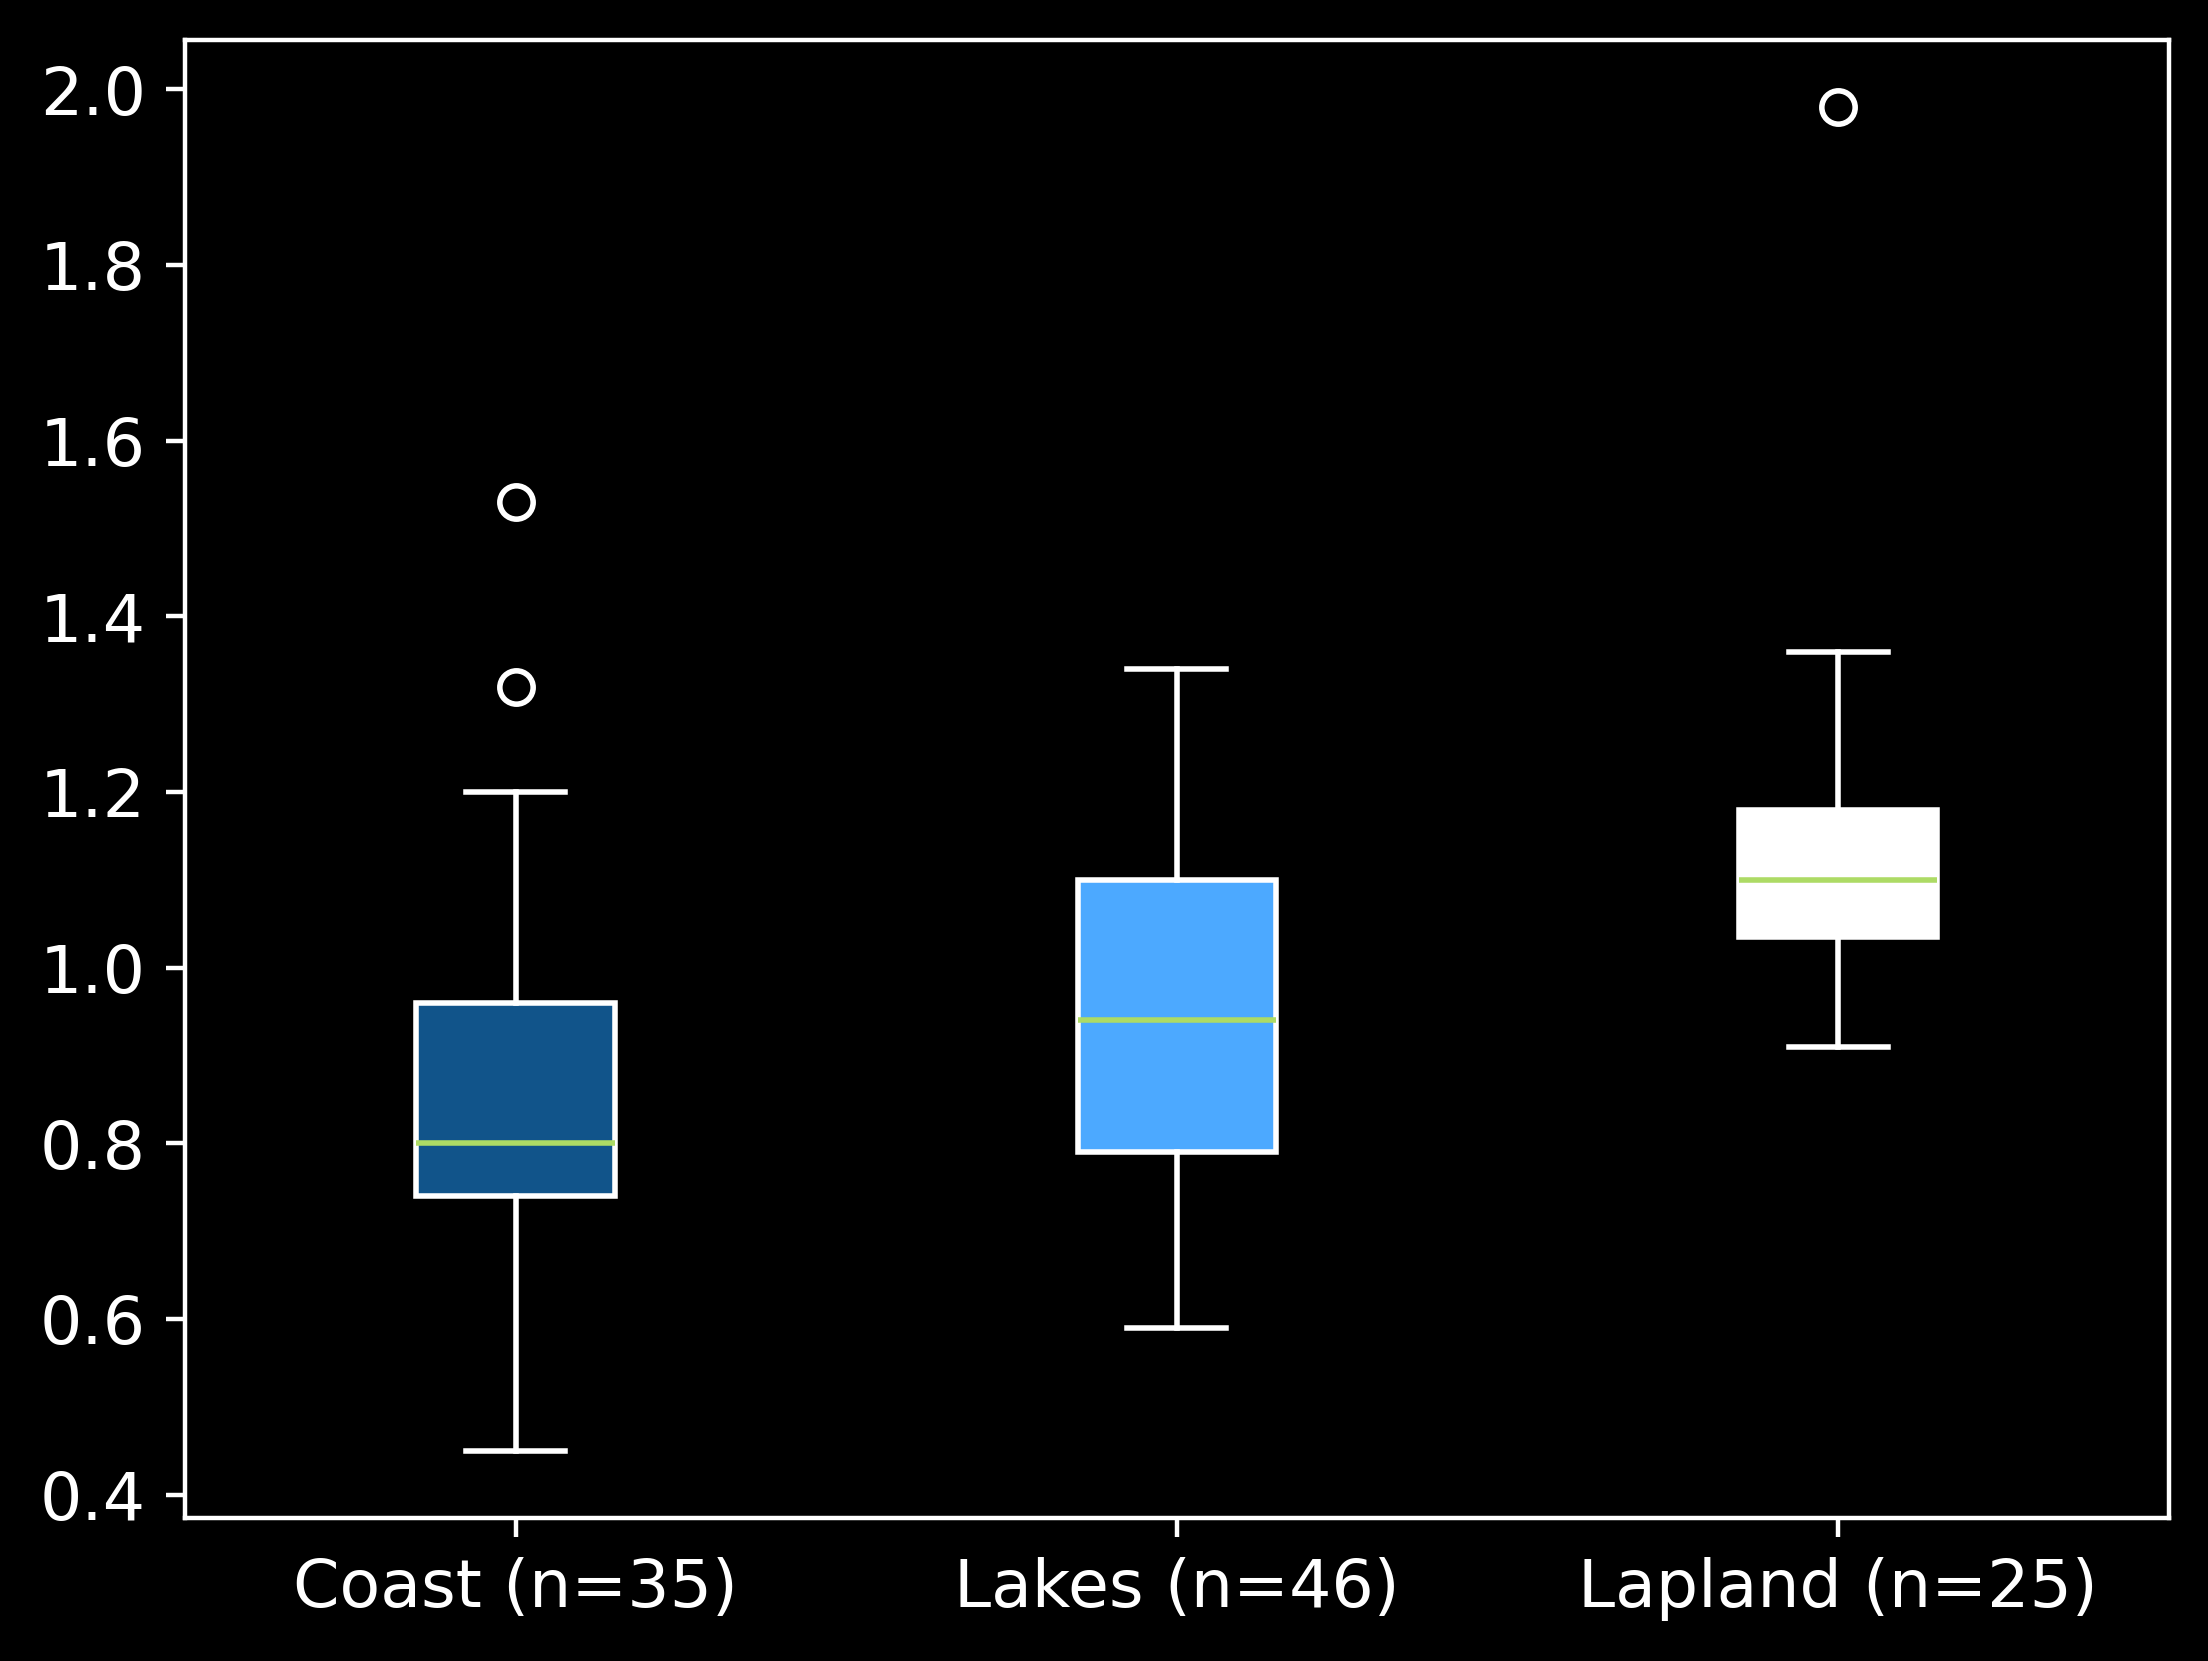

In [63]:

plot_data = preprocess(df, 'q_mean')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


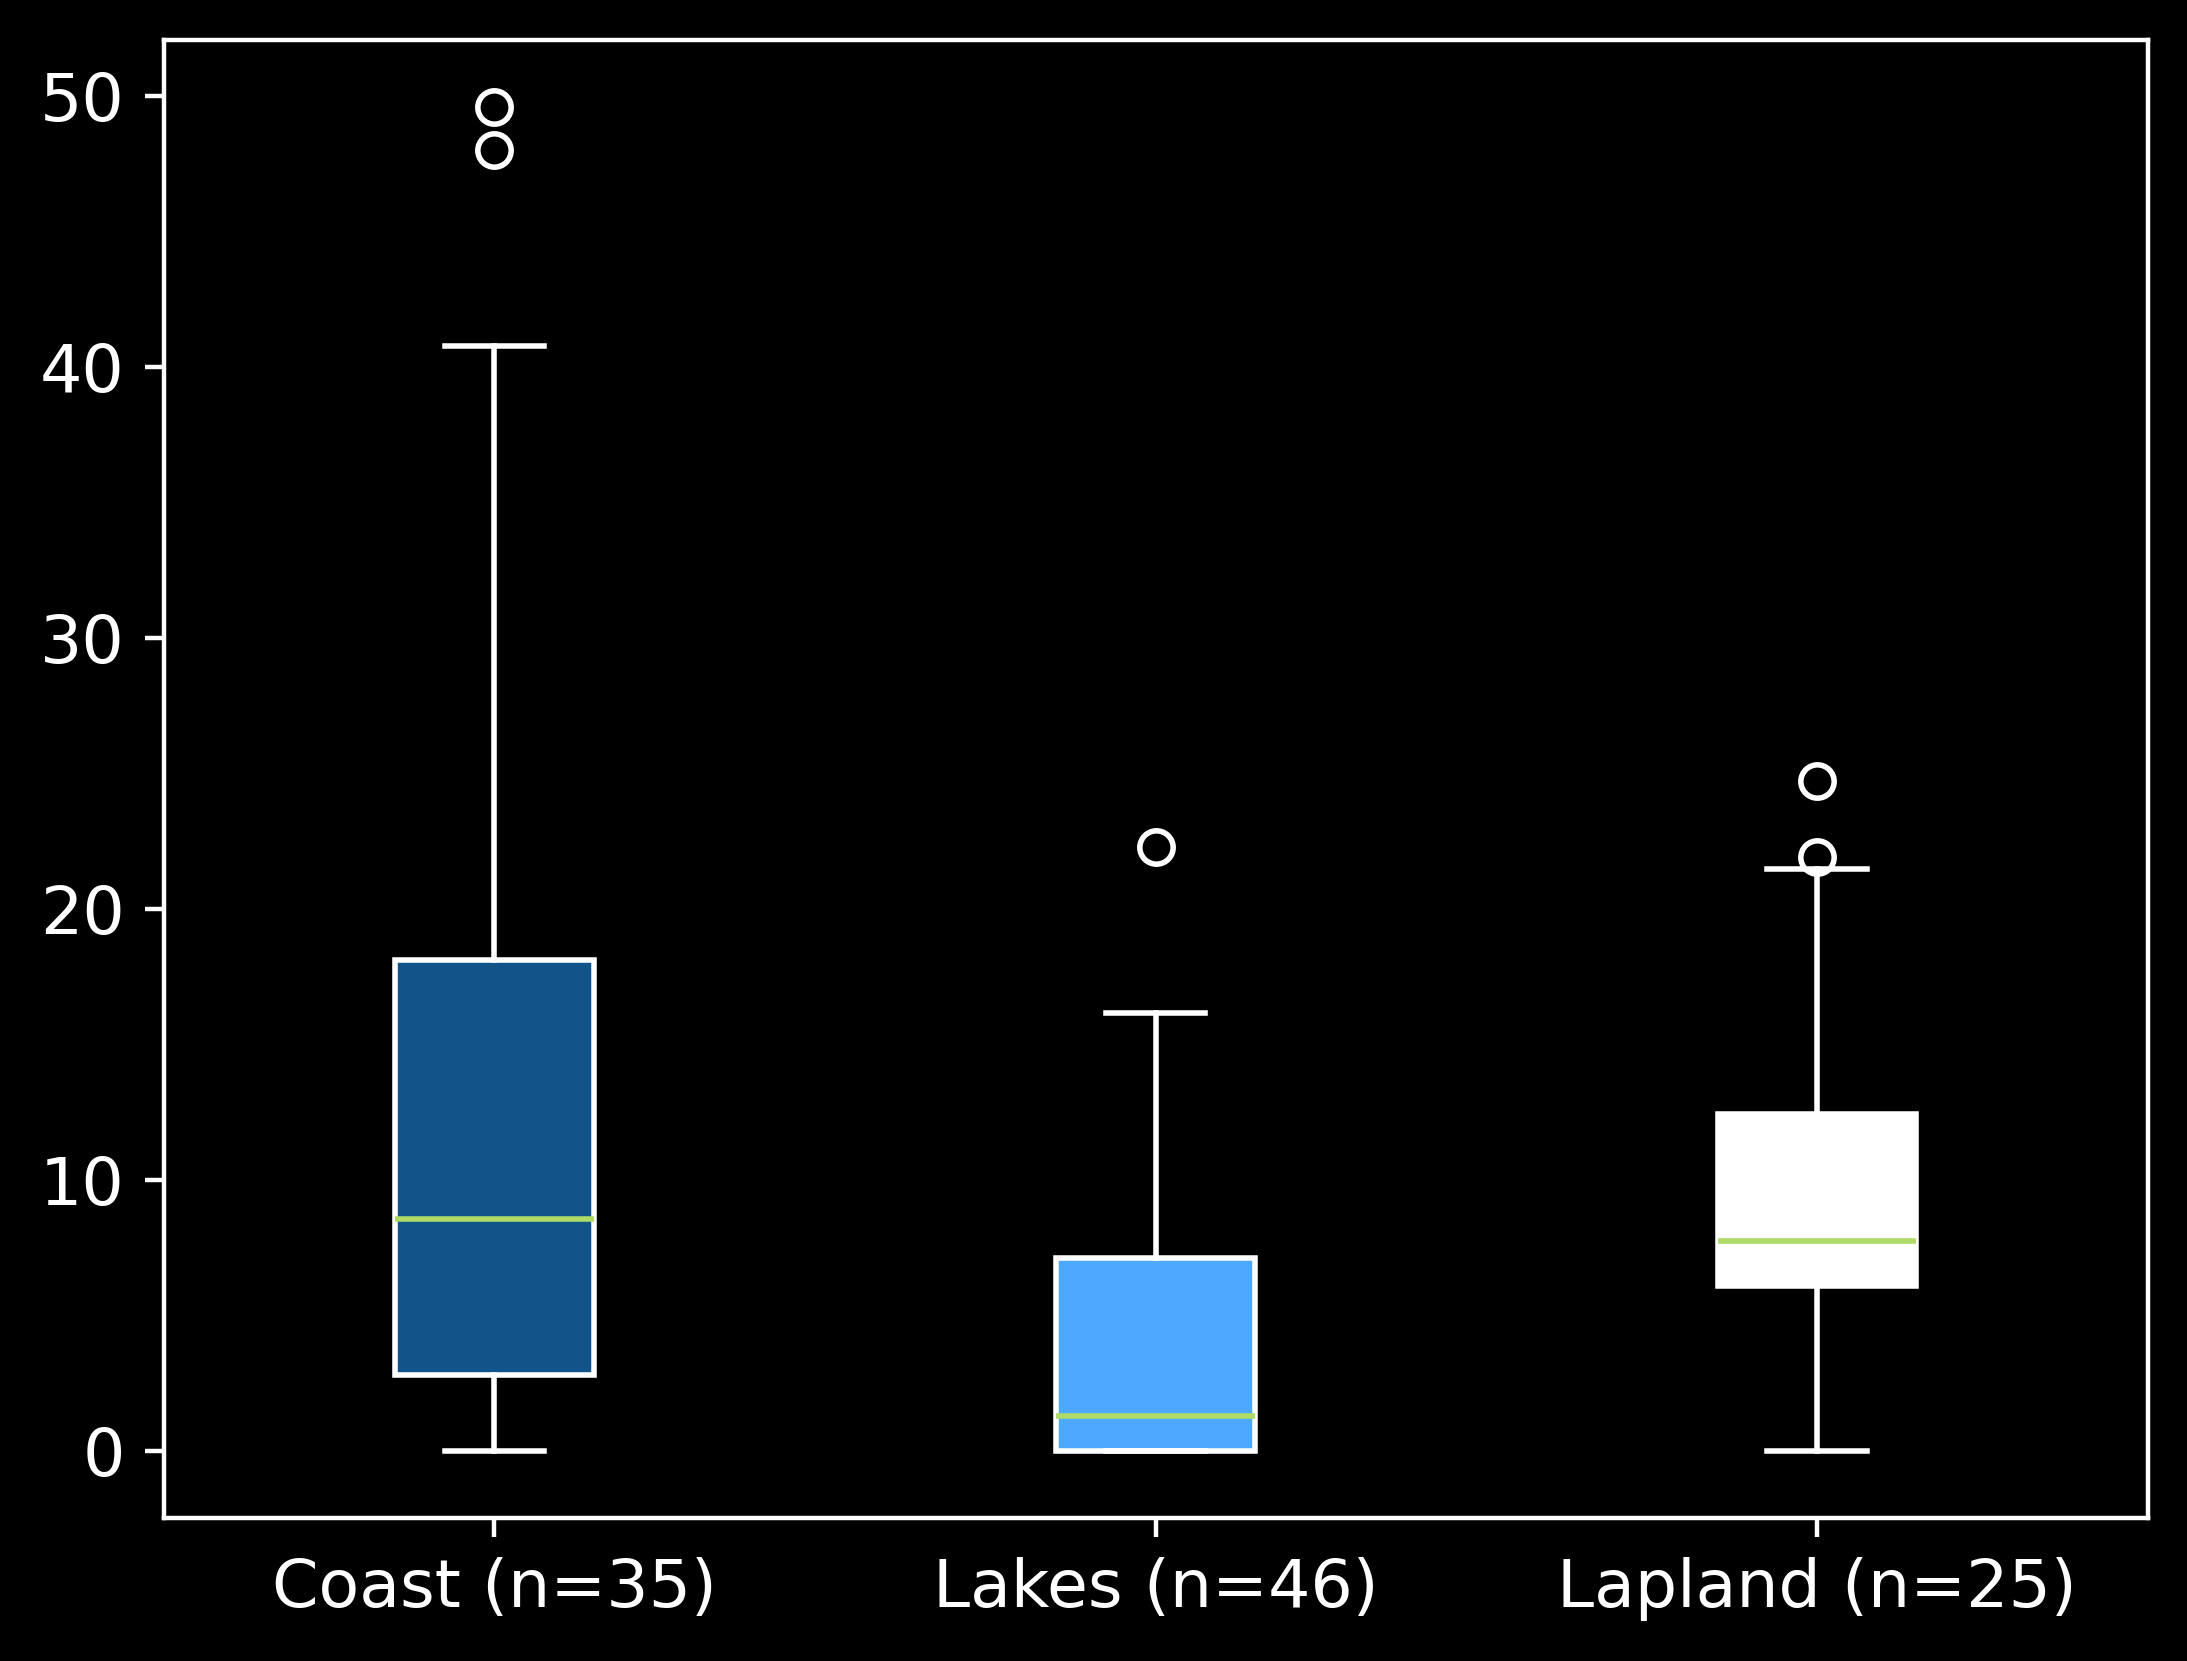

In [65]:

plot_data = preprocess(df, 'high_q_freq')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


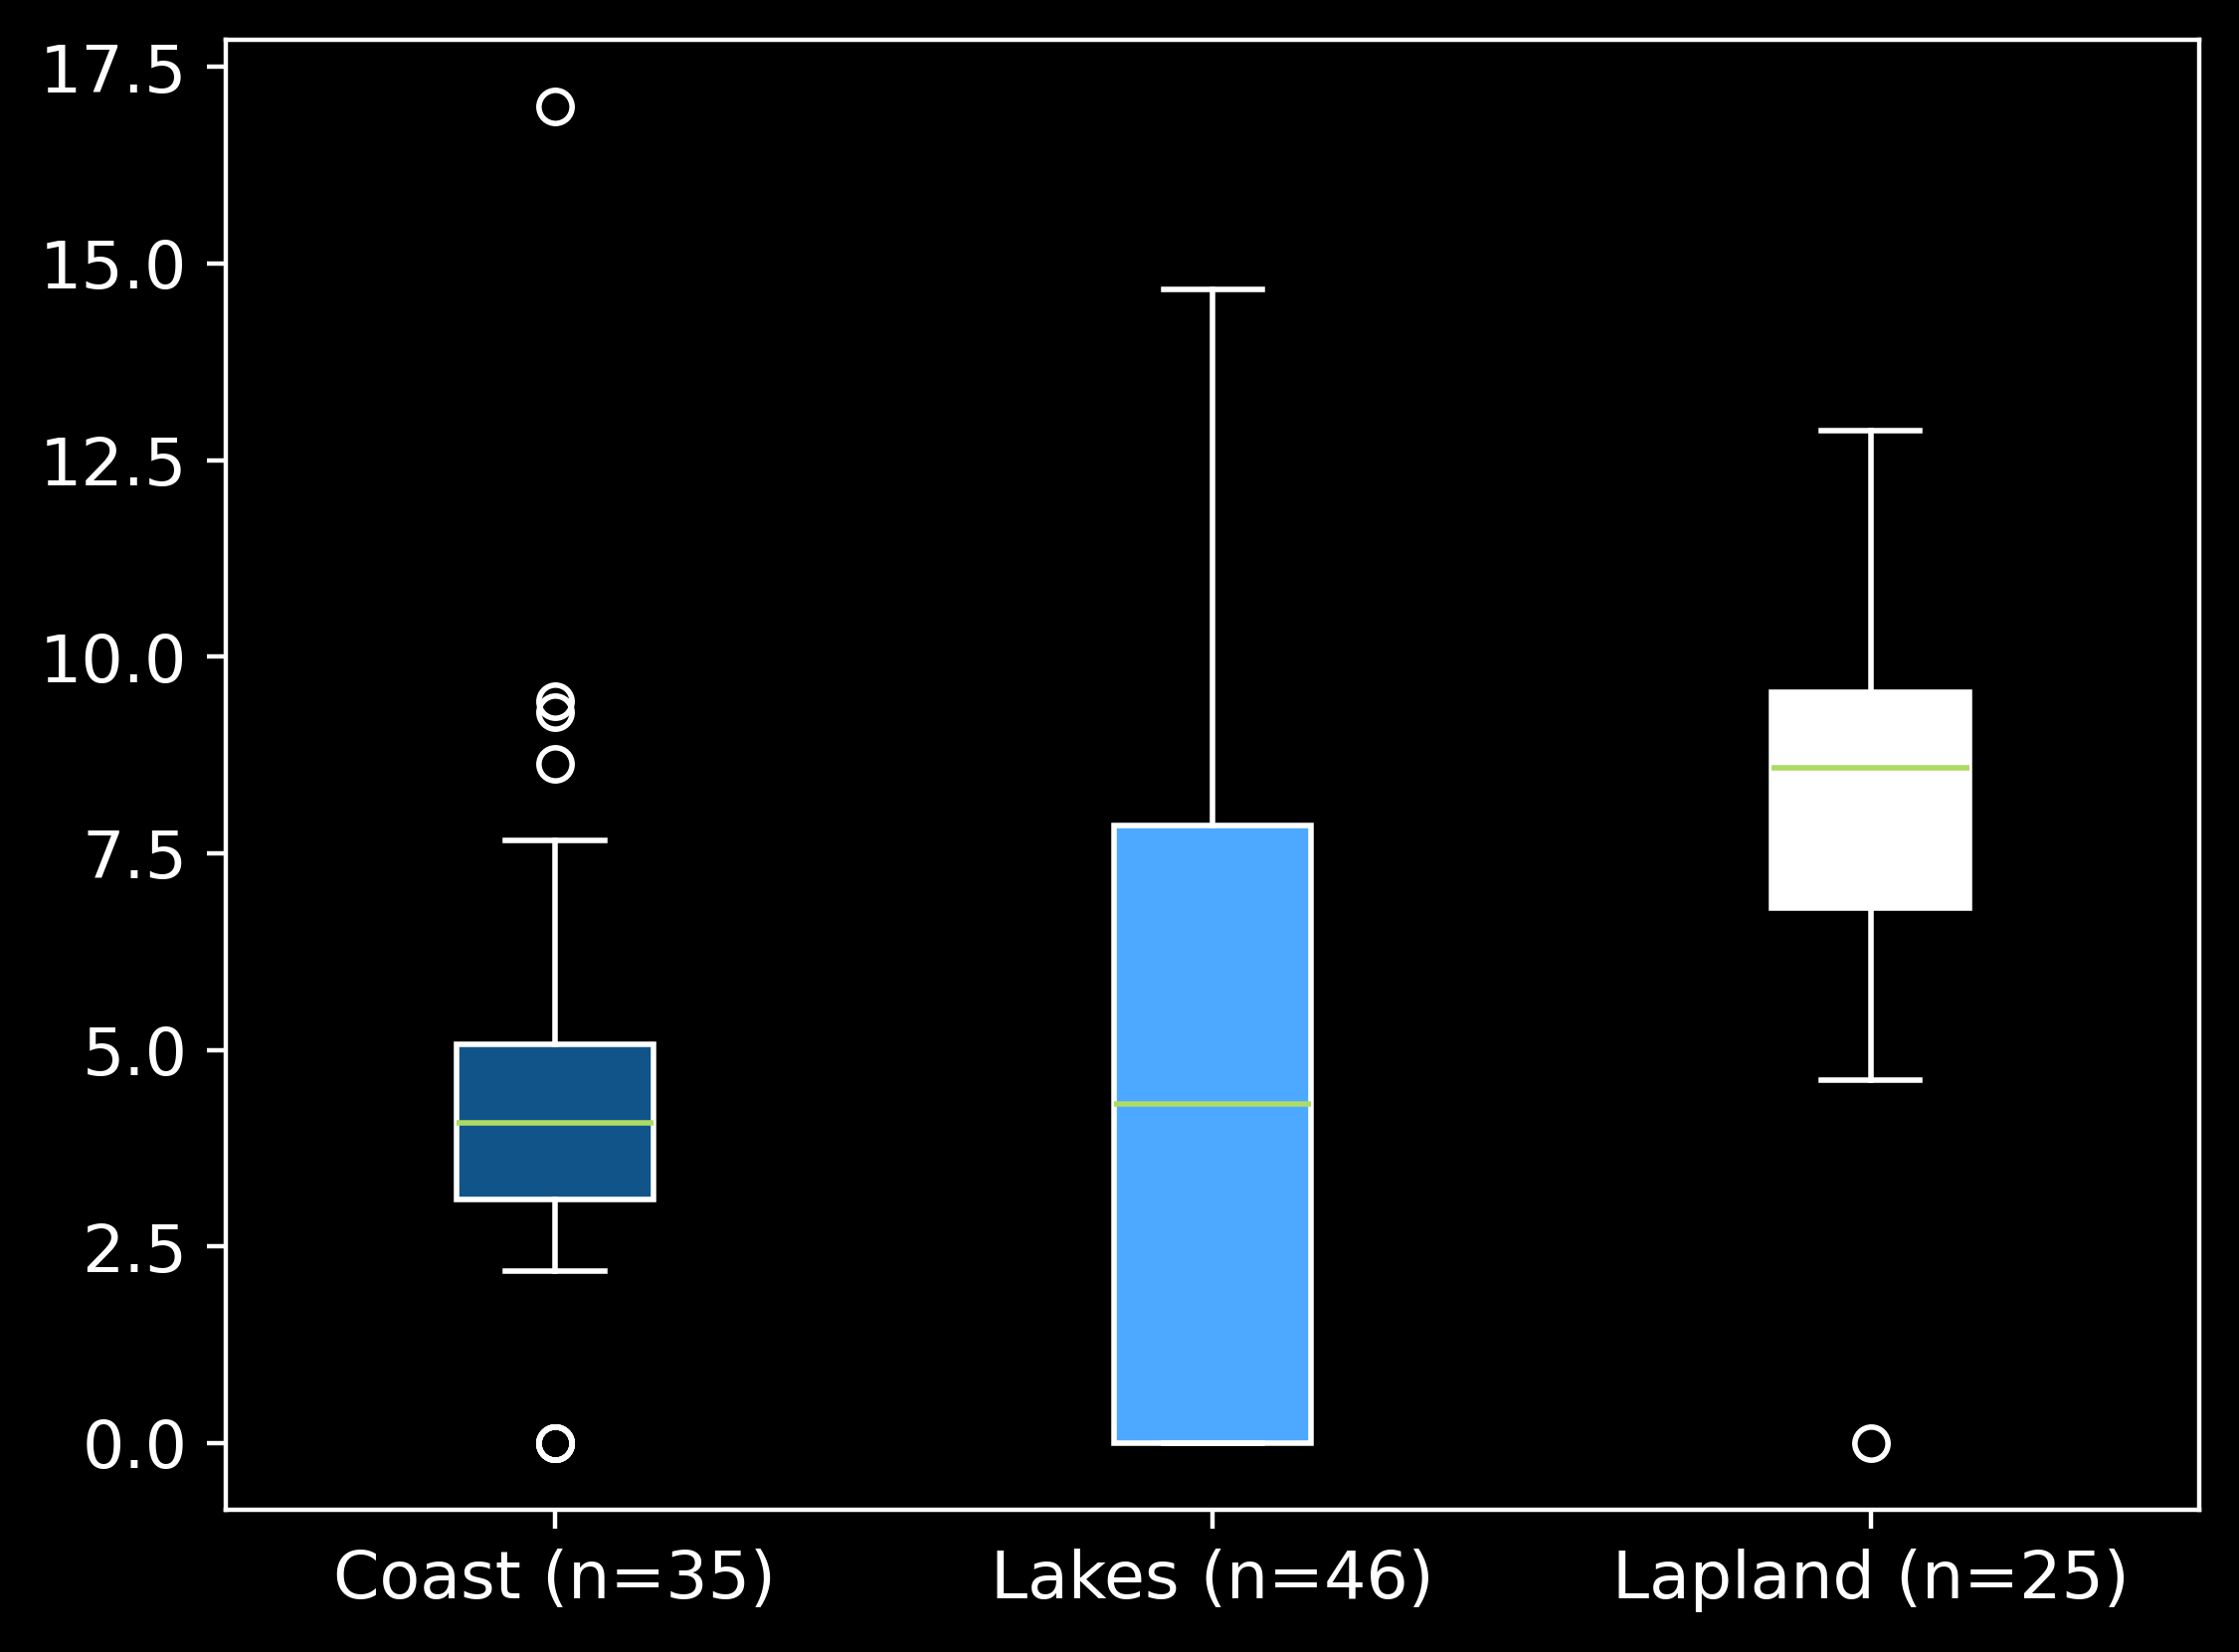

In [66]:

plot_data = preprocess(df, 'high_q_dur')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


# Climate

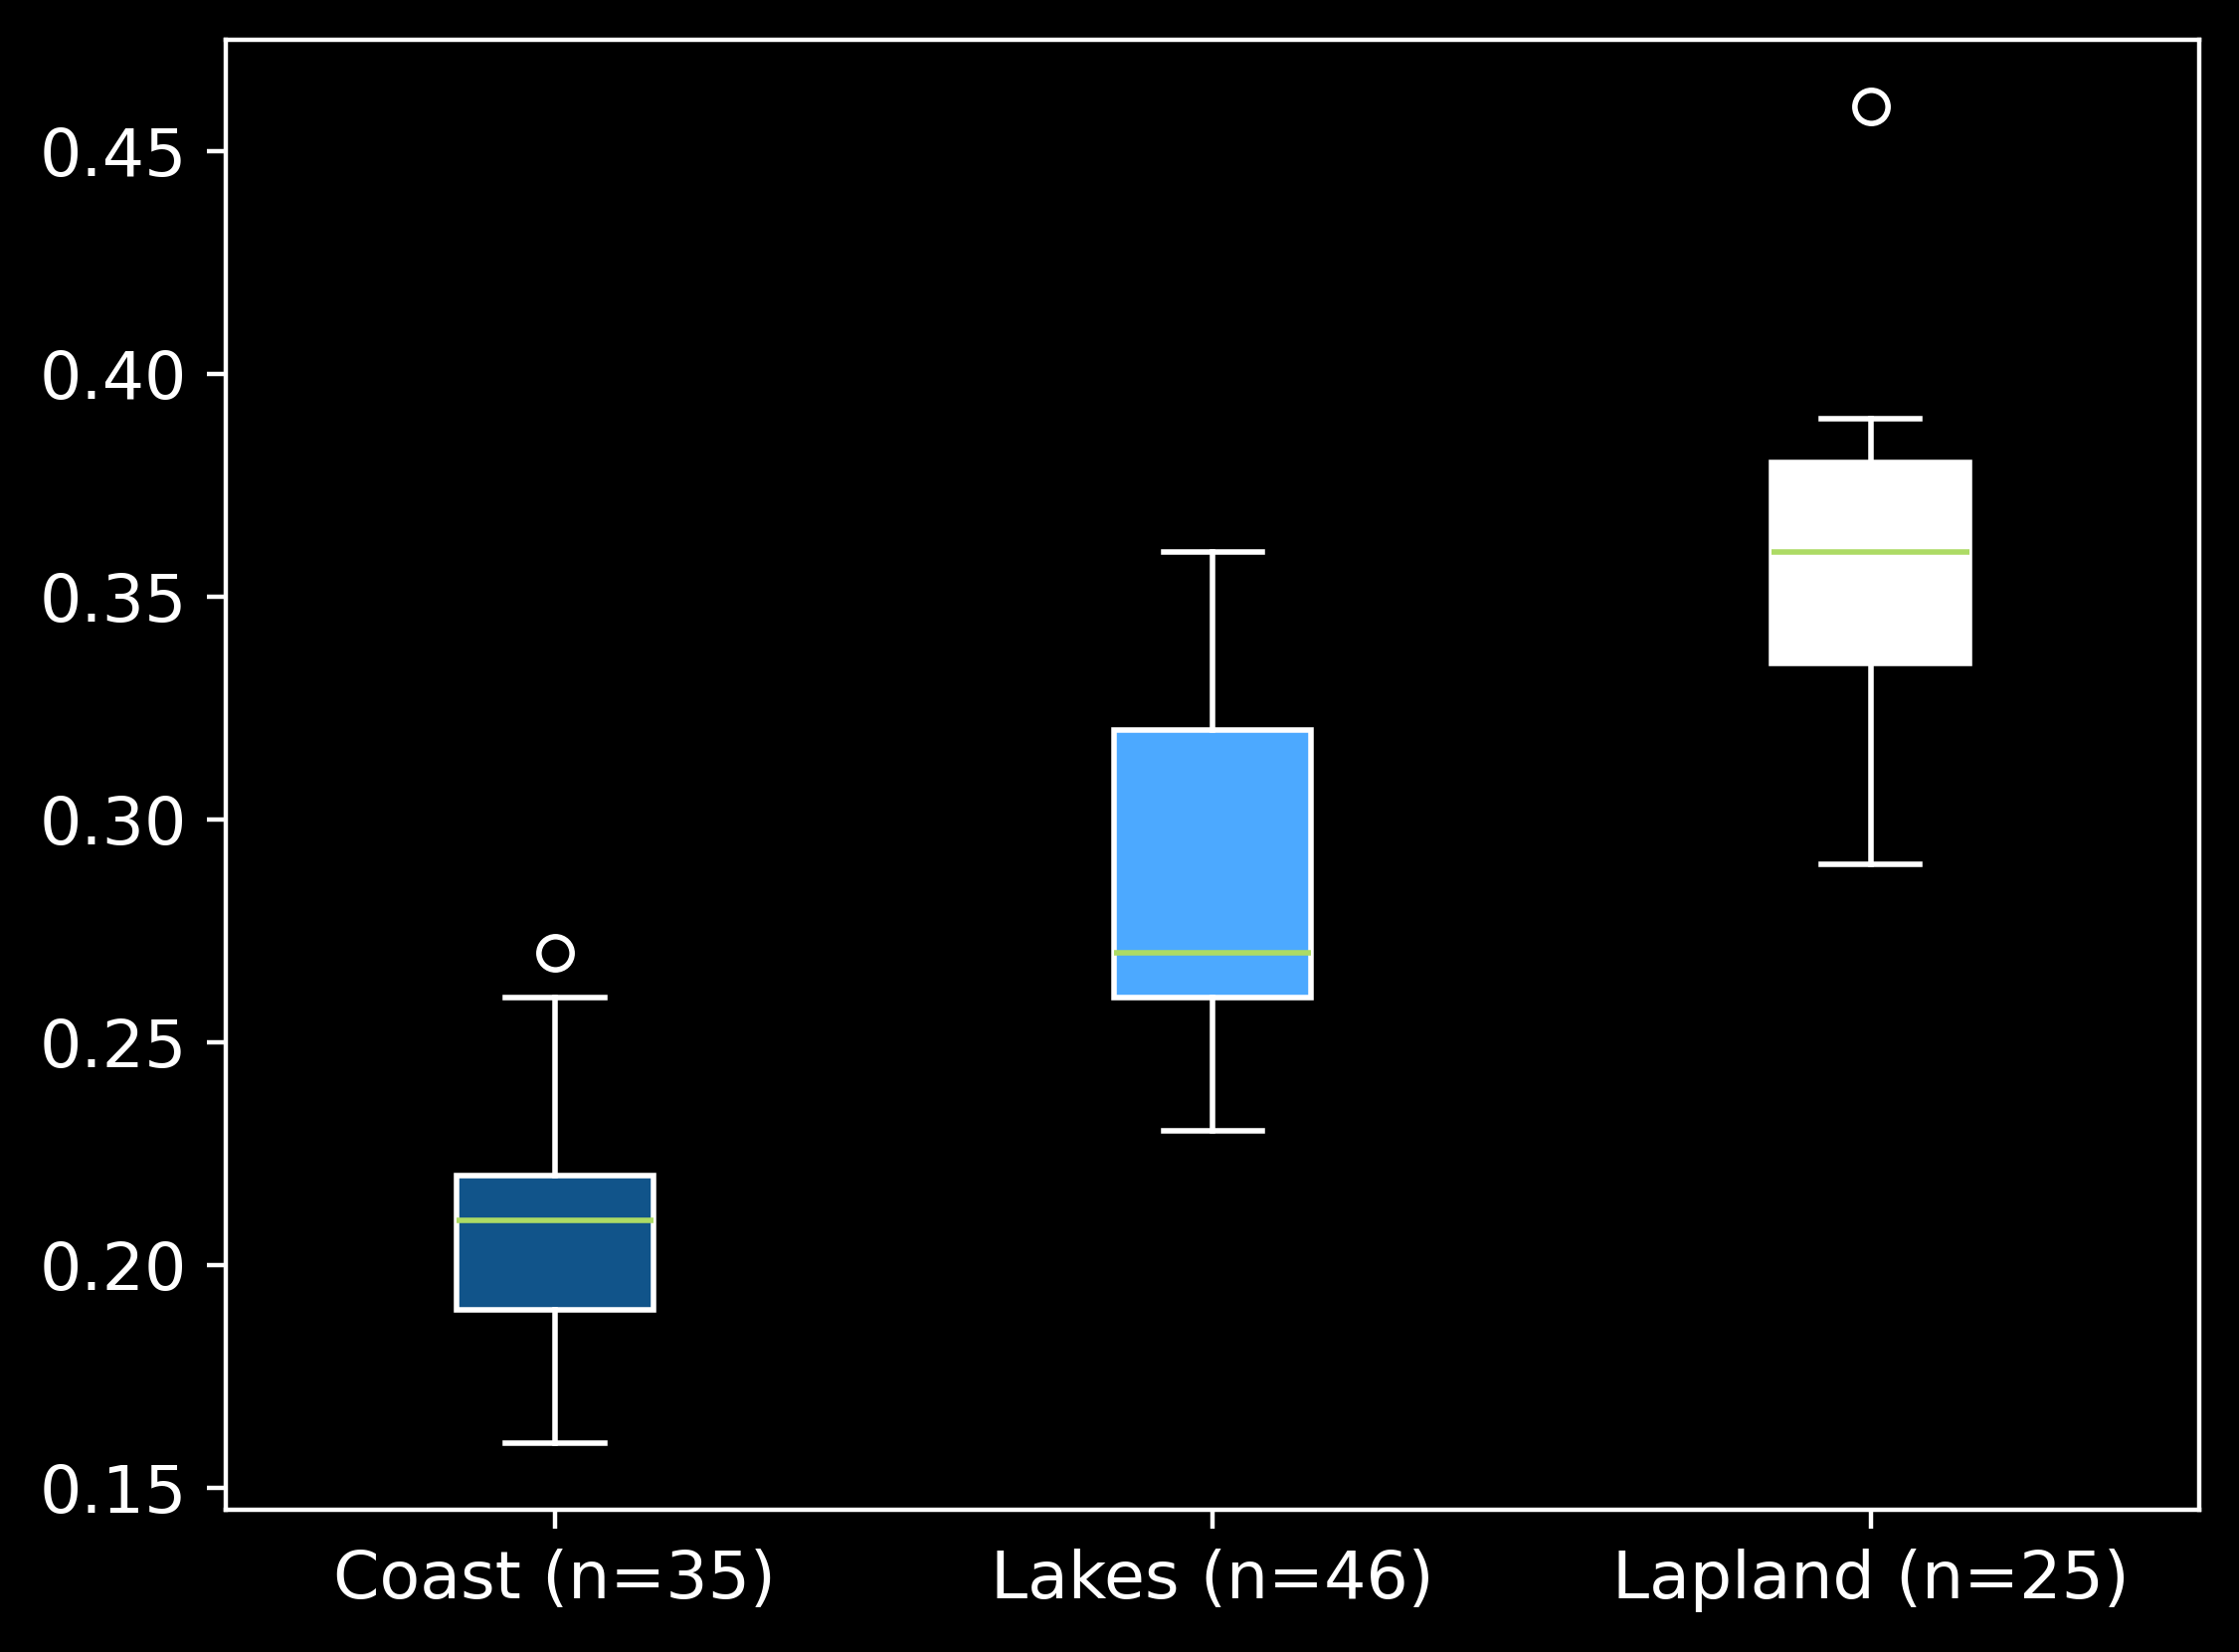

In [24]:

plot_data = preprocess(df, 'frac_snow')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


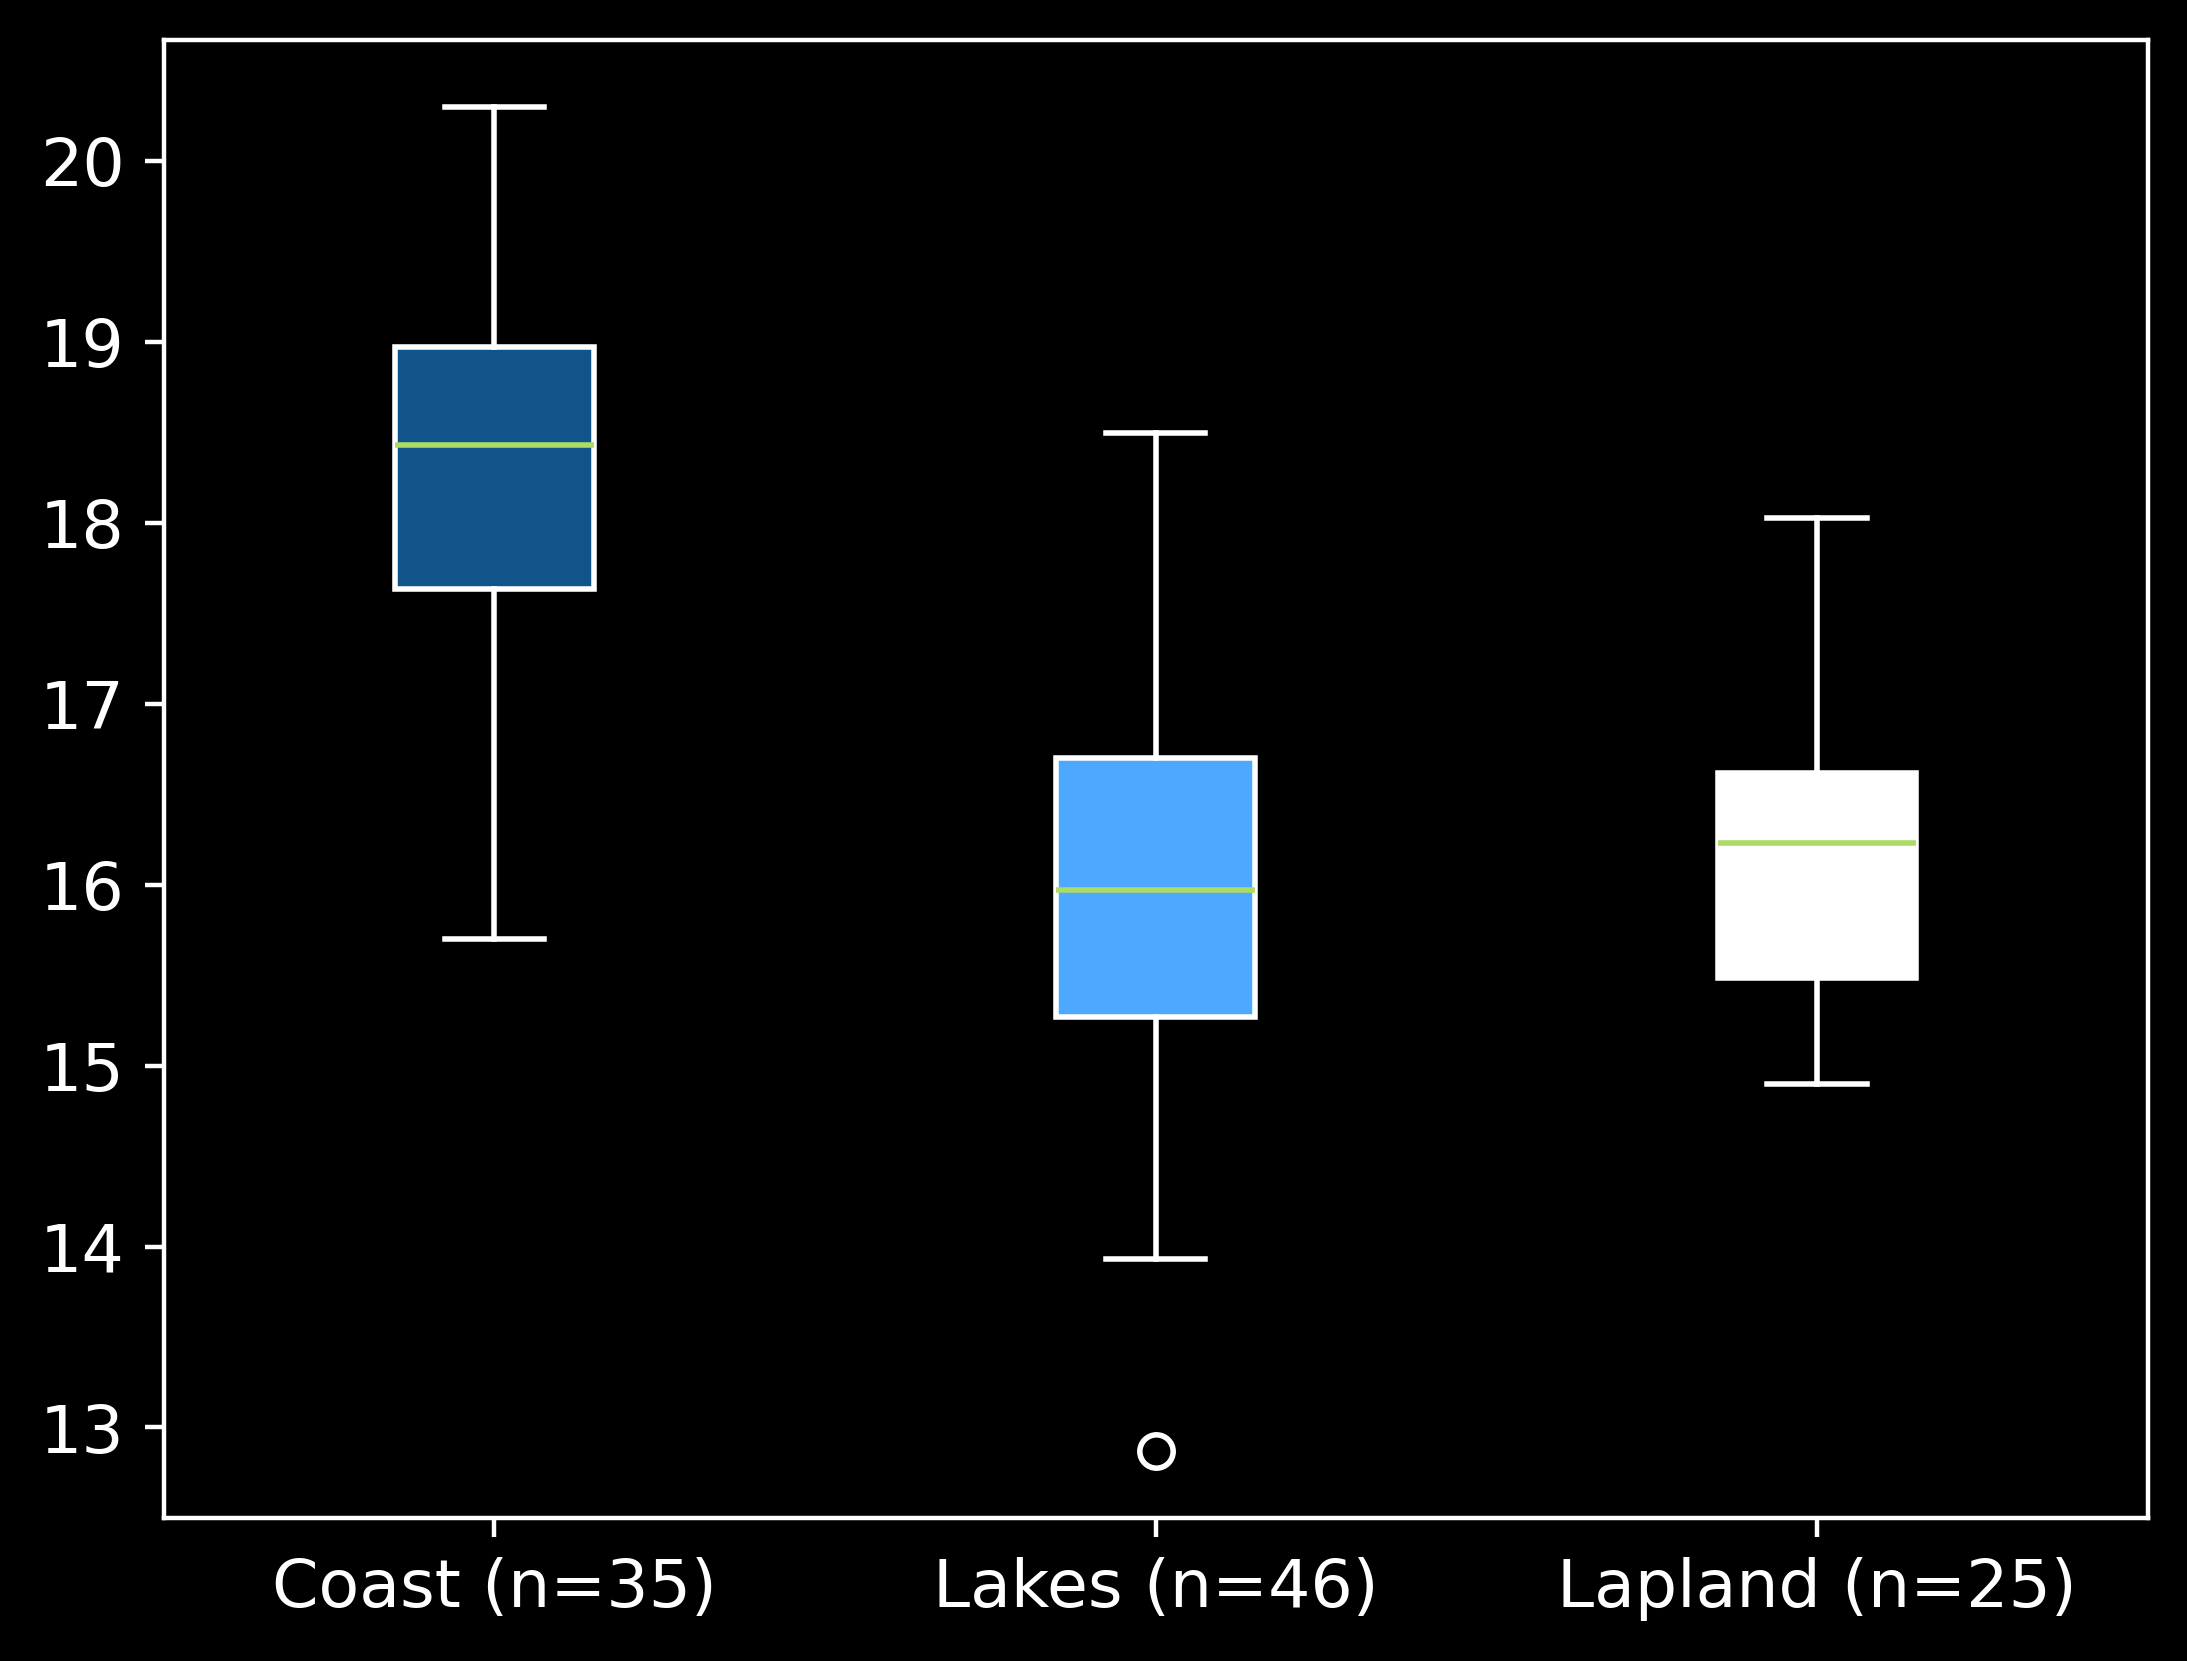

In [27]:

plot_data = preprocess(df, 'high_prec_freq')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)


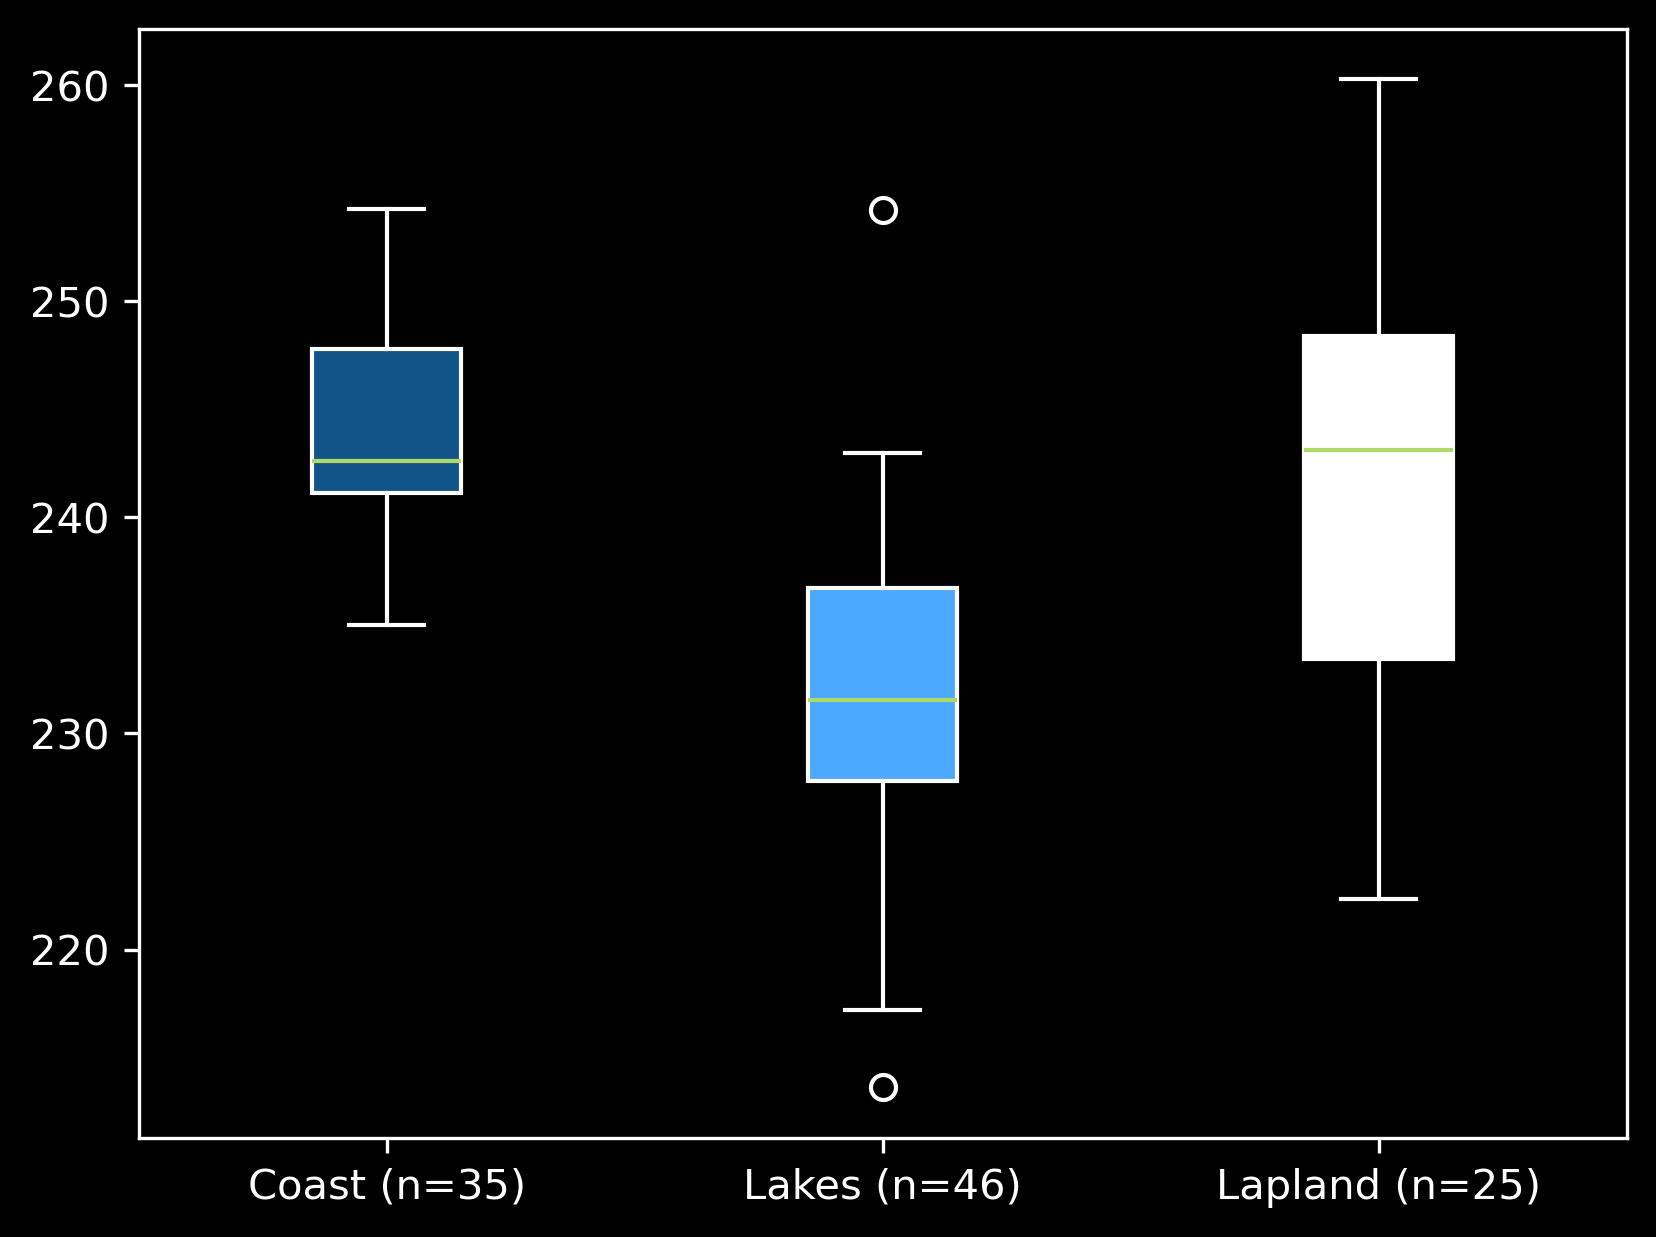

In [15]:

plot_data = preprocess(df, 'low_prec_freq')

colors = ['#11548a', '#4ca9ff', '#ffffff'] 
labels = ['Coast (n=35)', 'Lakes (n=46)', 'Lapland (n=25)']
fig, ax = plt.subplots()

bplot = ax.boxplot(
    plot_data, patch_artist=True, tick_labels=labels, medianprops=dict(color='#addb65'))
# fill with colors
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)
